# Seminário 4: Fundamentos de Machine Learning

**Disciplina:** Redes Neurais na Resolução de EDOs/EDPs — Doutorado PPGMC/UESC  
**Referência:** Goodfellow, Bengio & Courville. *Deep Learning*, Cap. 5 — Machine Learning Basics (2016, MIT Press)  
**Autor:** Guilherme de Sena Hughes

---

## Roteiro (~60 min)

| # | Tópico | Tempo |
|---|--------|-------|
| 1 | O que é aprendizado de máquina? | ~3 min |
| 2 | Algoritmos de Aprendizado + Regressão Linear | ~7 min |
| 3 | Capacidade, Overfitting e Underfitting | ~7 min |
| 4 | Hiperparâmetros e Conjuntos de Validação | ~5 min |
| 5 | Estimadores, Viés e Variância | ~5 min |
| 6 | Estimação por Máxima Verossimilhança | ~5 min |
| 7 | Estatística Bayesiana e MAP | ~5 min |
| 8 | Algoritmos Supervisionados e Não Supervisionados | ~5 min |
| 9 | Gradiente Descendente Estocástico | ~5 min |
| 10 | Construindo um Algoritmo de ML | ~5 min |
| 11 | Desafios que Motivam Deep Learning | ~8 min |

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print(f'PyTorch: {torch.__version__}')
print(f'CUDA disponível: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

PyTorch: 2.5.1+cu121
CUDA disponível: True
Dispositivo: cuda


---

## 1. O que é Aprendizado de Máquina? (~3 min)

A definição clássica de Mitchell (1997), citada por Goodfellow:

> *"Um programa de computador aprende com a experiência E em relação a uma classe de tarefas T e medida de desempenho P, se seu desempenho nas tarefas T, medido por P, melhora com a experiência E."*

Em ML, ao contrário de programação tradicional, **não codificamos as regras explicitamente**, deixamos o algoritmo inferí-las a partir dos dados.

```
Programação tradicional:  Dados + Regras  →  Respostas
Machine Learning:         Dados + Respostas →  Regras
```

---

## Algoritmos de Aprendizado (~7 min)

## A Tarefa (T) - The Task

O que o modelo deve fazer. Um exemplo é uma coleção de features medidas quantitativamente, representado como um vetor x ∈ Rⁿ.

- **Classificação**
  - Input: vetor x ∈ Rⁿ
  - Output: categoria y ∈ {1, ..., k}
  - Função: f: Rⁿ → {1, ..., k}
  - Exemplo: Reconhecimento de objetos
    - Input: imagem (valores de brilho dos pixels)
    - Output: código numérico identificando o objeto
    - Caso real: robô Willow Garage PR2 age como garçom, reconhece tipos de drinks e entrega sob comando

- **Classificação com inputs faltantes**
  - Input: vetor x ∈ Rⁿ com algumas entradas xᵢ faltando
  - Output: categoria y ∈ {1, ..., k}
  - Diferença: precisa aprender um conjunto de funções (uma para cada subconjunto possível de inputs faltantes)
  - Solução eficiente: aprender p(x) conjunta e marginalizar as variáveis faltantes → com n variáveis, obtemos todas as 2ⁿ funções de classificação necessárias
  - Exemplo: Diagnóstico médico
    - Input: resultados de exames (alguns podem não estar disponíveis porque são caros ou invasivos)
    - Output: diagnóstico

- **Regressão**
  - Input: vetor x ∈ Rⁿ
  - Output: valor numérico y ∈ R
  - Função: f: Rⁿ → R
  - Exemplo: Previsão de sinistros de seguro
    - Input: dados do segurado
    - Output: valor esperado do sinistro (usado para definir prêmios)
  - Exemplo: Previsão de preços de ativos financeiros
    - Input: dados históricos do mercado
    - Output: preço futuro (usado em trading algorítmico)

- **Transcrição**
  - Input: representação não estruturada de dados
  - Output: forma textual discreta
  - Exemplo: OCR (Reconhecimento Óptico de Caracteres)
    - Input: fotografia contendo texto
    - Output: sequência de caracteres (ASCII/Unicode)
    - Caso real: Google Street View usa deep learning para processar números de endereço
  - Exemplo: Reconhecimento de fala
    - Input: forma de onda de áudio
    - Output: sequência de caracteres ou códigos de palavras
    - Caso real: sistemas de fala da Microsoft, IBM e Google usam deep learning

- **Tradução automática**
  - Input: sequência de símbolos em um idioma
  - Output: sequência de símbolos em outro idioma
  - Exemplo: Tradução inglês → francês
    - Input: sentença em inglês
    - Output: sentença em francês

- **Saída estruturada (Structured output)**
  - Input: dados (texto, imagem, etc.)
  - Output: vetor ou estrutura com relações importantes entre seus elementos
  - Engloba transcrição e tradução, mas vai além
  - Exemplo: Parsing de linguagem natural
    - Input: sentença em linguagem natural
    - Output: árvore gramatical com nós rotulados (verbo, substantivo, advérbio, etc.)
  - Exemplo: Segmentação pixel a pixel de imagens
    - Input: imagem (ex: foto aérea)
    - Output: cada pixel atribuído a uma categoria (ex: estrada, prédio, vegetação)
    - Caso real: deep learning para anotar localização de estradas em fotos aéreas
  - Exemplo: Image captioning
    - Input: imagem
    - Output: sentença em linguagem natural descrevendo a imagem

- **Detecção de anomalias**
  - Input: conjunto de eventos ou objetos
  - Output: flag indicando quais são incomuns ou atípicos
  - Exemplo: Detecção de fraude em cartão de crédito
    - Input: histórico de compras do usuário + nova compra
    - Output: compra é legítima ou fraudulenta
    - Como funciona: modela a distribuição de compras do usuário; compras com distribuição diferente são flagadas

- **Síntese e amostragem**
  - Input: dados de treinamento (exemplos existentes)
  - Output: novos exemplos similares aos do treinamento
  - Exemplo: Geração de texturas para videogames
    - Input: exemplos de texturas
    - Output: novas texturas para objetos ou paisagens grandes (sem artista manual)
  - Exemplo: Síntese de fala
    - Input: sentença escrita
    - Output: forma de onda de áudio falando a sentença
    - Nota: não existe um único output correto — variação é desejada para parecer natural

- **Imputação de valores faltantes**
  - Input: exemplo x ∈ Rⁿ com algumas entradas xᵢ faltando
  - Output: predição dos valores das entradas faltantes

- **Denoising (remoção de ruído)**
  - Input: exemplo corrompido x̃ ∈ Rⁿ (obtido por processo de corrupção desconhecido)
  - Output: exemplo limpo x ∈ Rⁿ, ou a distribuição condicional $p(x \mid \tilde{x})$

- **Estimação de densidade / função de massa de probabilidade**
  - Input: conjunto de exemplos
  - Output: função p_modelo: $R^n → R$ que pode ser interpretada como densidade de probabilidade
  - O algoritmo precisa aprender a estrutura dos dados: onde exemplos se concentram e onde são improváveis
  - Nota: a maioria das outras tarefas exige capturar implicitamente a distribuição; estimação de densidade a captura explicitamente
  - Conexão: com $p(x)$ estimada, podemos resolver imputação de valores via $p(x_i \mid x_{-i})$
  - Limitação prática: operações sobre $p(x)$ frequentemente são computacionalmente intratáveis



## A Medida de Desempenho (P)

Como avaliamos o modelo. A métrica P é específica à tarefa T.

- **Acurácia**: proporção de exemplos classificados corretamente
  - Usada em: classificação, classificação com inputs faltantes, transcrição
  - Equivalente: taxa de erro (error rate) = 1 - acurácia = expected 0-1 loss

- **Log-probabilidade média**: score contínuo por exemplo
  - Usada em: estimação de densidade (onde acurácia não faz sentido)

- **Regra fundamental:** medir no **conjunto de teste** (dados nunca vistos), não no treino - isso determina performance no mundo real

- **Dificuldades na escolha de P:**
  - Transcrição: medir acurácia da sequência inteira ou dar crédito parcial por elementos corretos?
  - Regressão: penalizar mais erros médios frequentes ou erros grandes raros?
  - Estimação de densidade: muitos modelos representam p(x) apenas implicitamente → calcular o valor real de probabilidade pode ser intratável → necessário critério alternativo


## A Experiência (E)

De onde o modelo aprende. Dois tipos principais:

- **Aprendizado Supervisionado**
  - Dataset: pares $(x, y)$ onde $y$ é o rótulo/target
  - Objetivo: aprender $p(y | x)$ - prever $y$ a partir de $x$
  - O target $y$ é fornecido por um "instrutor" que mostra ao sistema o que fazer
  - Exemplo: dataset Iris com 150 plantas, 4 features + espécie como rótulo

- **Aprendizado Não Supervisionado**
  - Dataset: apenas exemplos ${x}$, sem rótulos
  - Objetivo: aprender $p(x)$ ou propriedades úteis da estrutura dos dados
  - Tarefas: estimação de densidade, clustering, denoising, síntese
  - Exemplo: aprender a distribuição de probabilidade que gerou os dados

- **A fronteira é borrada**
  - Regra da cadeia: $\prod_{i=1}^{n} p(x_i \mid x_1, \ldots, x_{i-1}$ → problema não supervisionado vira n problemas supervisionados
  - Inversamente: $p(y|x) = p(x,y) / Σ p(x,y')$ → problema supervisionado pode ser resolvido com técnicas não supervisionadas (aprender distribuição conjunta)

- **Exemplo: Por que a fronteira é borrada?**
   - Dados de pacientes com 3 variáveis (sem rótulos): temperatura, pressão arterial e frequência cardíaca.
  
 - **Não supervisionado → Supervisionado (regra da cadeia):**
   - Queremos modelar $p(\text{temp}, \text{pressão}, \text{freq})$ — problema não supervisionado. Mas pela regra da cadeia:
    $$p(\text{temp}, \text{pressão}, \text{freq}) = p(\text{temp}) \cdot p(\text{pressão} \mid \text{temp}) \cdot p(\text{freq} \mid \text{temp}, \text{pressão})$$
  
   - Cada termo é um problema de predição (supervisionado): prever uma variável dadas as anteriores. O mesmo problema não supervisionado virou 3 problemas supervisionados.
  
 - **Supervisionado → Não supervisionado (distribuição conjunta):**
  
   - Queremos prever $p(\text{gripe} \mid \text{temp})$ — problema supervisionado. Em vez de treinar um classificador, podemos aprender $p(\text{gripe}, \text{temp})$ de forma não supervisionada e calcular:
  
$$p(\text{gripe} \mid \text{temp}) = \frac{p(\text{gripe}, \text{temp})}{\sum_{\text{gripe'}} p(\text{gripe'}, \text{temp})}$$
 
  Problema supervisionado resolvido com técnica não supervisionada.

- **Outras variantes:**
  - Semi-supervisionado: alguns exemplos têm target, outros não
  - Multi-instance: uma coleção inteira é rotulada, mas membros individuais não
  - Aprendizado por reforço: interação com ambiente, loop de feedback (fora do escopo do livro)

- **Matriz de design (Design Matrix)**
  - Representação padrão: $X \in \mathbb{R}^{m \times n}$ - cada linha é um exemplo, cada coluna é uma feature
  - Exemplo: Iris → $X \in \mathbb{R}^{150 \times 4}$
  - Limitação: todos os exemplos devem ter o mesmo tamanho de vetor (imagens com dimensões diferentes não cabem)
  - Alternativa: conjunto $\{x^{(1)}, x^{(2)}, \ldots, x^{(m)}\}$ onde vetores podem ter tamanhos diferentes

### O Conjunto de Dados

Um dataset é tipicamente representado como uma **matriz de design** $X \in \mathbb{R}^{m \times n}$, onde:
- $m$ = número de exemplos
- $n$ = número de features

Cada exemplo $x^{(i)} \in \mathbb{R}^n$ é um vetor de features.

## Exemplo: Regressão Linear

Demonstração de T, P e E juntos.

- **Tarefa (T):** prever $y \in R$ a partir de $x \in Rⁿ$
  - Modelo: $ŷ = \omegaᵀx$ (função linear)
  - Parâmetros: $\omega \in Rⁿ$ (vetor de pesos)
  - $\omega_i$ > 0 → aumentar $x_i$ aumenta $\hat{y}$
  - $\omega_i$ < 0 → aumentar $x_i$ diminui $\hat{y}$
  - $\omega_i$ = 0 → feature $x_i$ não afeta a predição

- **Desempenho (P):** MSE no conjunto de teste
  - $\text{MSE}_{\text{test}} = \frac{1}{m} \|\hat{y}^{(\text{test})} - y^{(\text{test})}\|_2^2$
  - Erro = 0 quando predições = targets
  - Erro cresce com a distância euclidiana entre predições e targets

- **Experiência (E):** conjunto de treinamento $(X^{(\text{train})}, y^{(\text{train})})$
  - Estratégia: minimizar MSE_train (justificado depois na seção 5.5.1 sobre MLE)

- **Solução (equações normais):**
  - $\nabla_w \text{MSE}_{\text{train}} = 0$
  - $w^* = (X^{(\text{train})\top} X^{(\text{train})})^{-1} X^{(\text{train})\top} y^{(\text{train})}$

- **Extensão com bias:**
  - $\hat{y} = wᵀx + b$ (função afim - a reta não precisa passar pela origem)
  - Equivalente a adicionar uma feature extra sempre = 1 ao vetor $x$
  - "bias" aqui é o viés da transformação afim, diferente do viés estatístico de um estimador


w* (equações normais) = 1.3449
MSE_train no ótimo    = 0.1841


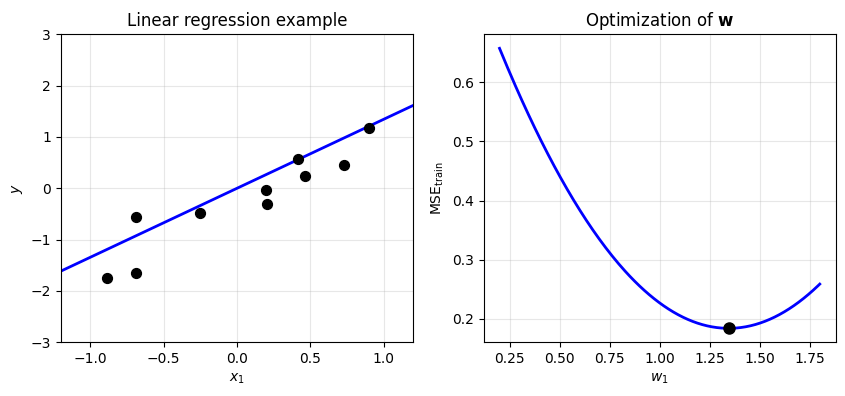

In [4]:
"""
Reprodução da Figura 5.1 — Deep Learning (Goodfellow, Bengio & Courville)
Regressão linear: dados de treino + reta ajustada (esquerda)
                   MSE_train em função de w1 (direita)
"""                                                                

import numpy as np                                                 # Importa NumPy para operações numéricas com arrays
import matplotlib.pyplot as plt                                    # Importa Matplotlib para criação de gráficos

np.random.seed(42)                                                 # Fixa a semente do gerador aleatório para resultados reproduzíveis

# --- Dados de treino: 10 pontos, 1 feature ---
m = 10                                                             # Define o número de amostras de treino
x_train = np.random.uniform(-1, 1, m)                             # Gera 10 valores aleatórios uniformes entre -1 e 1 (os inputs)
w_true = 1.0                                                      # Define a inclinação real usada para gerar os dados
y_train = w_true * x_train + np.random.randn(m) * 0.5             # Calcula y = 1.0*x + ruído gaussiano (média 0, desvio 0.5)

# --- Solução analítica (equações normais, sem bias) ---
# ŷ = w1 * x  →  w* = (XᵀX)⁻¹Xᵀy
w_star = (x_train @ y_train) / (x_train @ x_train)                # Calcula o peso ótimo pela fórmula fechada: w* = (xᵀy)/(xᵀx)

# --- Curva de MSE em função de w1 ---
w_range = np.linspace(0.2, 1.8, 200)                              # Cria 200 valores de w1 entre 0.2 e 1.8 para varrer o espaço de parâmetros
mse_values = np.array([np.mean((w * x_train - y_train)**2) for w in w_range])  # Para cada w, calcula o MSE médio sobre os dados de treino

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))                   # Cria uma figura com 2 subplots lado a lado (10x4 polegadas)

# Esquerda: dados + reta ajustada
ax1 = axes[0]                                                     # Seleciona o subplot da esquerda
ax1.scatter(x_train, y_train, color='black', s=50, zorder=5)      # Plota os 10 pontos de treino como círculos pretos (s=tamanho, zorder=camada acima)
x_line = np.linspace(-1.2, 1.2, 100)                              # Cria 100 pontos entre -1.2 e 1.2 para desenhar a reta suavemente
ax1.plot(x_line, w_star * x_line, 'b-', lw=2)                     # Desenha a reta ajustada y = w* · x em azul com espessura 2
ax1.set_xlabel('$x_1$')                                           # Define o rótulo do eixo X com notação LaTeX
ax1.set_ylabel('$y$')                                             # Define o rótulo do eixo Y
ax1.set_title('Linear regression example')                         # Define o título do subplot esquerdo
ax1.set_xlim(-1.2, 1.2)                                           # Fixa os limites do eixo X de -1.2 a 1.2
ax1.set_ylim(-3, 3)                                               # Fixa os limites do eixo Y de -3 a 3
ax1.grid(True, alpha=0.3)                                         # Ativa a grade de fundo com transparência de 30%

# Direita: MSE_train em função de w1
ax2 = axes[1]                                                     # Seleciona o subplot da direita
ax2.plot(w_range, mse_values, 'b-', lw=2)                         # Plota a curva de MSE em função de w1 (parábola azul)
mse_star = np.mean((w_star * x_train - y_train)**2)               # Calcula o valor do MSE no ponto ótimo w*
ax2.plot(w_star, mse_star, 'ko', ms=8, zorder=5)                  # Marca o ponto mínimo (w*, MSE*) como um círculo preto de tamanho 8
ax2.set_xlabel('$w_1$')                                           # Rótulo do eixo X: o parâmetro w1
ax2.set_ylabel('$\\mathrm{MSE}_{\\mathrm{train}}$')               # Rótulo do eixo Y: MSE de treino (LaTeX formatado)
ax2.set_title('Optimization of $\\mathbf{w}$')                    # Título: "Otimização de w" com w em negrito (LaTeX)
ax2.grid(True, alpha=0.3)                                         # Grade de fundo com 30% de transparência

print(f'w* (equações normais) = {w_star:.4f}')                    # Imprime o valor ótimo de w com 4 casas decimais
print(f'MSE_train no ótimo    = {mse_star:.4f}')                  # Imprime o MSE mínimo com 4 casas decimais

### Exemplo Canônico: Regressão Linear 

A regressão linear como o primeiro algoritmo de aprendizado completo. O modelo assume:

$$\hat{y} = \omega^T{x}  \quad \text{onde} \quad w \in \mathbb{R}^n \quad \text{é um vetor de parâmetros}$$

Os parâmetros são valores que controlam o comportamento do sistema, o $\omega_i$ é o coeficiente que multiplica o parâmetro $x_i$ antes de somar as contribuições de todos os parâmetros.

A função de custo é o erro quadrático médio (MSE):

$$\mathcal{L}(w) = \frac{1}{m} \|\hat{y} - y\|_2^2 = \frac{1}{m} \|Xw - y\|_2^2$$

Derivando e igualando a zero, obtemos a **solução em forma fechada** (equações normais):

$$\nabla_w \mathcal{L} = 0 \implies w^* = (X^\top X)^{-1} X^\top y$$

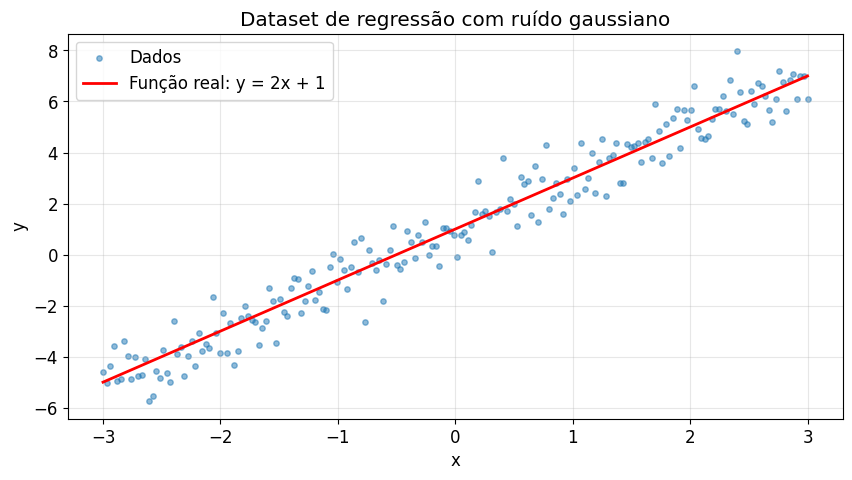

Shape de X: torch.Size([200, 1])  →  200 exemplos, 1 feature
Shape de y: torch.Size([200, 1])


In [7]:
# Criando um dataset simples de regressão
# y = 2x + 1 + ruído gaussiano. A função geradora é uma reta com inclinação 2, intercepto 1, mais ruído

m = 200                                                            # Define o número de amostras (200 pontos de dados)
X_np = np.linspace(-3, 3, m).reshape(-1, 1)                       # Cria 200 valores igualmente espaçados de -3 a 3 e reshape para coluna (200x1)
y_np = 2 * X_np + 1 + np.random.randn(m, 1) * 0.8                # Calcula y = 2x + 1 + ruído gaussiano (média 0, desvio 0.8), resultado shape (200x1)

X = torch.tensor(X_np, dtype=torch.float32)                       # Converte o array NumPy X_np para tensor PyTorch do tipo float32
y = torch.tensor(y_np, dtype=torch.float32)                       # Converte o array NumPy y_np para tensor PyTorch do tipo float32

plt.scatter(X_np, y_np, alpha=0.5, s=15, label='Dados')           # Plota os 200 pontos como dispersão (50% transparência, tamanho 15, com legenda)
plt.plot(X_np, 2*X_np + 1, 'r-', lw=2, label='Função real: y = 2x + 1')  # Desenha a reta real (sem ruído) em vermelho com espessura 2
plt.xlabel('x')                                                   # Define o rótulo do eixo X
plt.ylabel('y')                                                   # Define o rótulo do eixo Y
plt.title('Dataset de regressão com ruído gaussiano')              # Define o título do gráfico
plt.legend()                                                       # Exibe a legenda (com os labels definidos no scatter e plot)
plt.grid(True, alpha=0.3)                                         # Ativa a grade de fundo com 30% de transparência
plt.show()                                                         # Renderiza e exibe o gráfico na tela

print(f'Shape de X: {X.shape}  →  {m} exemplos, 1 feature')       # Imprime o shape do tensor X: torch.Size([200, 1])
print(f'Shape de y: {y.shape}')                                    # Imprime o shape do tensor y: torch.Size([200, 1])

Solução analítica (equações normais):
  w (inclinação) = 2.0304  (real: 2.0)
  b (intercepto)  = 0.9674  (real: 1.0)


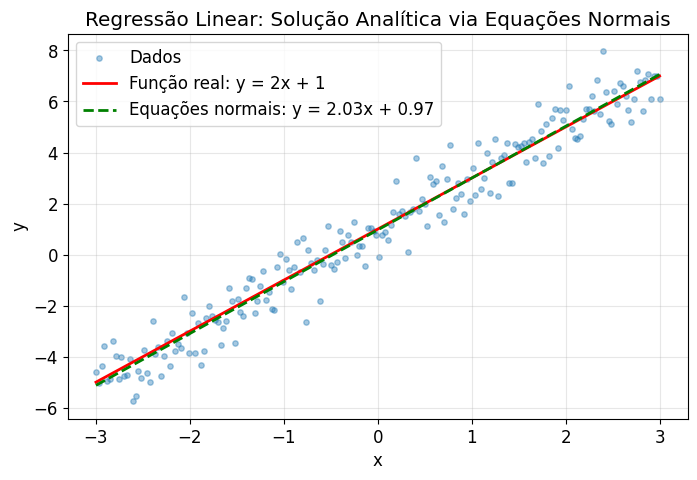

MSE no dataset: 0.5492


In [8]:
# Regressão Linear: solução analítica via equações normais
# Adicionando a coluna de 1s para o bias (intercepto). Agora o modelo inclui bias, então y = w*x + b

X_bias = np.hstack([X_np, np.ones((X_np.shape[0], 1))])           # Concatena horizontalmente X_np (200x1) com coluna de 1s (200x1), resultado (200x2): cada linha é [x_i, 1]

# Equações normais: w* = (X^T X)^{-1} X^T y
# Ao invés de calcular a inversa explicitamente, considerando a mesma instável
# usa o np.linalg.solve(A, b), resolvendo o sistema linear
# Aw = b diretamente
w_star = np.linalg.solve(X_bias.T @ X_bias, X_bias.T @ y_np)     # Resolve o sistema (XᵀX)w = Xᵀy sem inverter a matriz (mais estável numericamente), resultado shape (2x1)

# Resultado é um vetor de 2 valores (matriz):
# w_star[0] = inclinação da reta
# w_star[1] = é o intercepto

print(f'Solução analítica (equações normais):')                    # Imprime o cabeçalho dos resultados
print(f'  w (inclinação) = {w_star[0, 0]:.4f}  (real: 2.0)')      # Imprime a inclinação estimada (w_star[0,0]) comparando com o valor real 2.0
print(f'  b (intercepto)  = {w_star[1, 0]:.4f}  (real: 1.0)')     # Imprime o intercepto estimado (w_star[1,0]) comparando com o valor real 1.0

# Predição
# Cada linha de X_bias (vetor [x_i, 1]) vezes o vetor w_star
# Resulta em ŷ_i = w_0 * x_i + w_1
y_pred_normal = X_bias @ w_star                                    # Multiplica a matriz (200x2) pelo vetor (2x1), gerando as 200 predições ŷ (200x1)


# Visualização
plt.figure(figsize=(8, 5))                                        # Cria uma nova figura de 8x5 polegadas
plt.scatter(X_np, y_np, alpha=0.4, s=15, label='Dados')           # Plota os pontos de treino (40% opacidade, tamanho 15)
plt.plot(X_np, 2*X_np + 1, 'r-', lw=2, label='Função real: y = 2x + 1')  # Desenha a reta real em vermelho
plt.plot(X_np, y_pred_normal, 'g--', lw=2, label=f'Equações normais: y = {w_star[0,0]:.2f}x + {w_star[1,0]:.2f}')  # Desenha a reta estimada em verde tracejado, com coeficientes no label
plt.xlabel('x')                                                   # Rótulo do eixo X
plt.ylabel('y')                                                   # Rótulo do eixo Y
plt.title('Regressão Linear: Solução Analítica via Equações Normais')  # Título do gráfico
plt.legend()                                                       # Exibe a legenda com as três entradas (dados, reta real, reta estimada)
plt.grid(True, alpha=0.3)                                         # Grade de fundo com 30% de transparência
plt.show()                                                         # Renderiza e exibe o gráfico

mse = np.mean((y_pred_normal - y_np)**2)                          # Calcula o erro quadrático médio entre predições e valores reais
print(f'MSE no dataset: {mse:.4f}')                               # Imprime o MSE com 4 casas decimais

---

## 2. Capacidade, Overfitting e Underfitting (~7 min)

O objetivo central de ML é que o modelo **generalize**, ou seja, que tenha bom desempenho em dados **nunca vistos**.

### Erro de Treinamento vs. Erro de Generalização

- **Erro de treinamento** ($\mathcal{L}_{train}$): erro medido nos dados de treino
- **Erro de generalização** ($\mathcal{L}_{test}$): erro esperado em novos dados (estimado pelo conjunto de teste)

### Capacidade do Modelo

**Capacidade** é a habilidade do modelo de se ajustar a uma grande variedade de funções. Modelos com pouca capacidade não conseguem capturar padrões complexos; modelos com capacidade excessiva memorizam os dados de treino.

| Situação | Erro Treino | Erro Teste | Causa |
|----------|-------------|------------|-------|
| **Underfitting** | Alto | Alto | Capacidade insuficiente |
| **Ideal** | Baixo | Baixo | Capacidade adequada |
| **Overfitting** | Baixo | Alto | Capacidade excessiva |

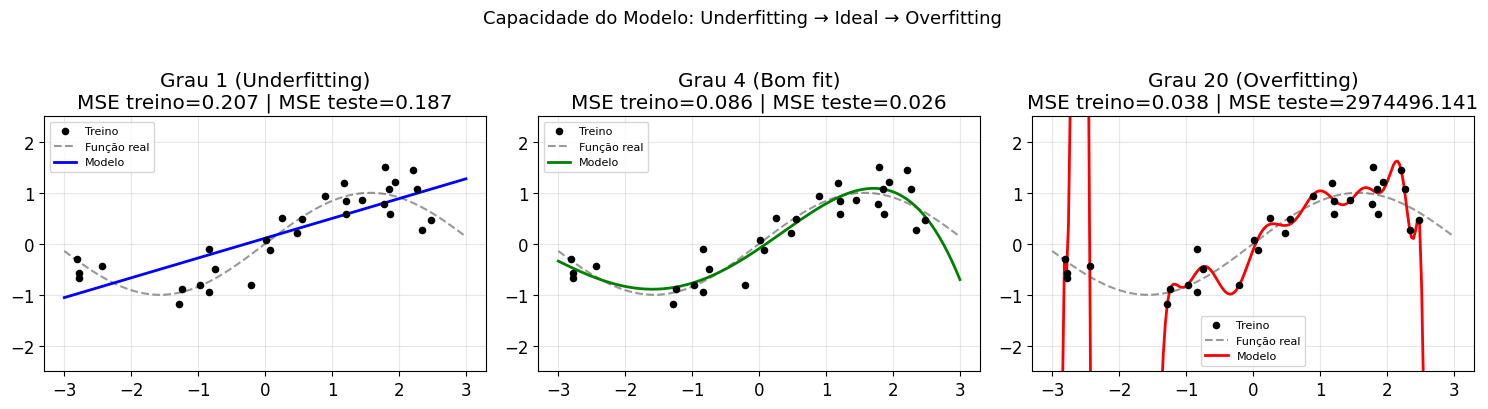

In [ ]:
# Demonstração de underfitting vs. overfitting via regressão polinomial
from numpy.polynomial import polynomial as P                      

X_train_np = np.sort(np.random.uniform(-3, 3, 30))                # Gera 30 valores aleatórios uniformes entre -3 e 3, ordenados em ordem crescente
y_train_np = np.sin(X_train_np) + np.random.randn(30) * 0.3       # Calcula y = sin(x) + ruído gaussiano (desvio 0.3). A função real é um seno

X_test_np = np.linspace(-3, 3, 200)                               # Cria 200 pontos igualmente espaçados de -3 a 3 para avaliar os modelos
y_true = np.sin(X_test_np)                                        # Calcula o seno puro (sem ruído) nesses 200 pontos, é a "verdade" para comparação

graus = [1, 4, 20]                                                 # Lista dos graus polinomiais a testar: 1 (simples demais), 4 (adequado), 20 (complexo demais)
labels = ['Grau 1 (Underfitting)', 'Grau 4 (Bom fit)', 'Grau 20 (Overfitting)']  # Rótulos descritivos para cada grau
cores = ['blue', 'green', 'red']                                   # Cores associadas: azul, verde e vermelho

fig, axes = plt.subplots(1, 3, figsize=(15, 4))                   # Cria figura com 3 subplots lado a lado (15x4 polegadas)

for ax, grau, label, cor in zip(axes, graus, labels, cores):       # Itera simultaneamente sobre subplots, graus, labels e cores
    coef = np.polyfit(X_train_np, y_train_np, grau)                # Ajusta um polinômio de grau 'grau' aos dados de treino, retorna coeficientes (do maior ao menor grau)
    y_pred_train = np.polyval(coef, X_train_np)                    # Avalia o polinômio ajustado nos pontos de treino (para calcular MSE de treino)
    y_pred_test = np.polyval(coef, X_test_np)                      # Avalia o polinômio ajustado nos pontos de teste (para calcular MSE de teste)

    train_mse = np.mean((y_train_np - y_pred_train)**2)            # Calcula o MSE de treino: média dos erros quadráticos entre y real e y predito no treino
    test_mse = np.mean((y_true - y_pred_test)**2)                  # Calcula o MSE de teste: média dos erros quadráticos entre função real (sin) e predição no teste

    ax.scatter(X_train_np, y_train_np, color='black', s=20, zorder=5, label='Treino')  # Plota os 30 pontos de treino como círculos pretos
    ax.plot(X_test_np, y_true, 'k--', alpha=0.4, label='Função real')                  # Desenha a curva sin(x) real como linha preta tracejada (40% opacidade)
    ax.plot(X_test_np, np.clip(y_pred_test, -3, 3), color=cor, lw=2, label='Modelo')   # Desenha a curva do modelo, cortando (clip) valores entre -3 e 3 para evitar explosão do grau 20
    ax.set_title(f'{label}\nMSE treino={train_mse:.3f} | MSE teste={test_mse:.3f}')    # Define título com o label e os dois valores de MSE formatados
    ax.set_ylim(-2.5, 2.5)                                        # Fixa os limites do eixo Y para facilitar comparação visual entre os 3 gráficos
    ax.legend(fontsize=8)                                          # Exibe a legenda com fonte tamanho 8
    ax.grid(True, alpha=0.3)                                       # Ativa grade de fundo com 30% de transparência

plt.suptitle('Capacidade do Modelo: Underfitting → Ideal → Overfitting', fontsize=13, y=1.02)  # Título geral acima dos 3 subplots (y=1.02 posiciona ligeiramente acima da figura)
plt.tight_layout()                                                 # Ajusta automaticamente o espaçamento entre subplots para evitar sobreposição
plt.show()                                                         # Renderiza e exibe a figura completa

### Regularização

Para controlar overfitting sem simplesmente reduzir a capacidade, usamos **regularização** - penalizamos a complexidade do modelo na função de perda:

$$\mathcal{L}_{reg}(\theta) = \mathcal{L}(\theta) + \lambda \cdot \Omega(\theta)$$

- **L2 (Ridge / Weight Decay):** $\Omega(\theta) = \|\theta\|_2^2$ — penaliza pesos grandes, encolhe-os em direção a zero
- **L1 (Lasso):** $\Omega(\theta) = \|\theta\|_1$ — promove esparsidade (alguns pesos vão exatamente a zero)

O hiperparâmetro $\lambda$ controla o trade-off entre ajuste aos dados e simplicidade do modelo.

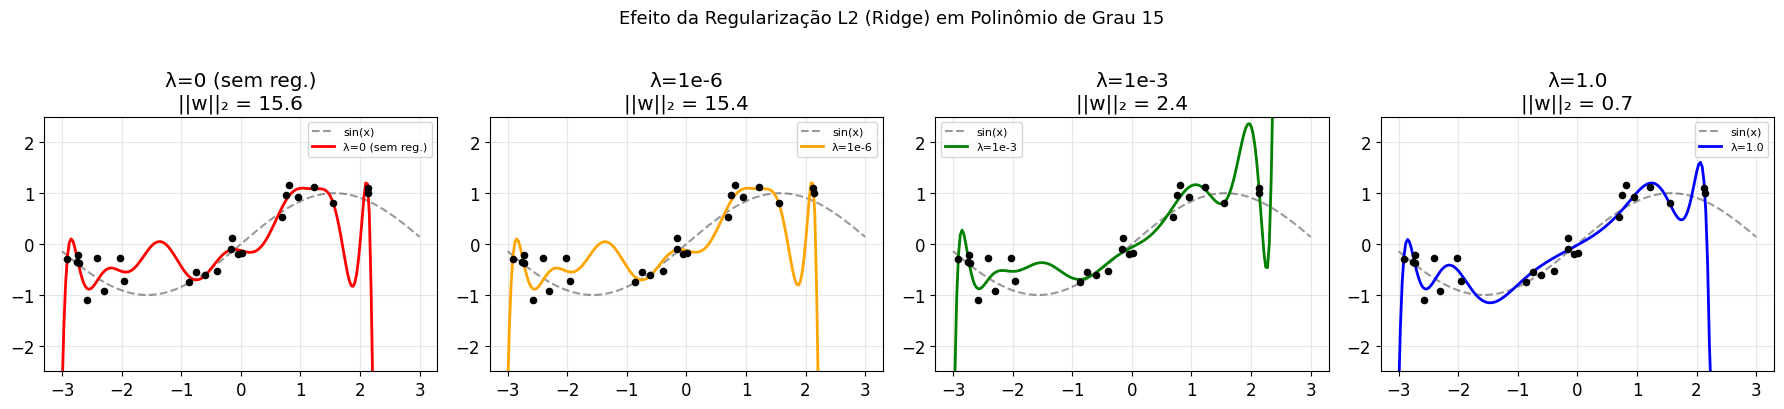

In [ ]:
# Efeito da regularização L2 na regressão polinomial
# Sem regularização, o polinômio de grau 20 explode (overfitting)
# Com regularização, os coeficientes são controlados               

from numpy.polynomial import polynomial as P                       

grau = 15                                                         # Define o grau do polinômio, alto o suficiente para causar overfitting sem regularização
X_train_reg = np.sort(np.random.uniform(-3, 3, 25))               # Gera 25 valores aleatórios uniformes entre -3 e 3, ordenados crescentemente
y_train_reg = np.sin(X_train_reg) + np.random.randn(25) * 0.3     # Calcula y = sin(x) + ruído gaussiano (desvio 0.3)
X_plot = np.linspace(-3, 3, 200)                                  # Cria 200 pontos espaçados de -3 a 3 para plotar as curvas suavemente

# Construir matriz de Vandermonde
def vandermonde(x, d):                                             # Define função que constrói a matriz de Vandermonde para um vetor x e grau d
    return np.vstack([x**i for i in range(d+1)]).T                 # Empilha verticalmente [x⁰, x¹, x², ..., xᵈ] e transpõe → resultado shape (n, d+1), cada linha é [1, xᵢ, xᵢ², ..., xᵢᵈ]

V_train = vandermonde(X_train_reg, grau)                           # Constrói a Vandermonde de treino: shape (25, 16) - 25 amostras, 16 colunas (grau 0 a 15)
V_plot  = vandermonde(X_plot, grau)                                # Constrói a Vandermonde para plotagem: shape (200, 16)

lambdas = [0, 1e-6, 1e-3, 1.0]                                    # Lista de valores de λ (intensidade da regularização): de nenhuma a forte
labels_reg = ['λ=0 (sem reg.)', 'λ=1e-6', 'λ=1e-3', 'λ=1.0']    # Rótulos descritivos para cada valor de λ
cores_reg = ['red', 'orange', 'green', 'blue']                    # Cores associadas a cada configuração

fig, axes = plt.subplots(1, 4, figsize=(18, 4))                   # Cria figura com 4 subplots lado a lado (18x4 polegadas)

for ax, lam, lab, cor in zip(axes, lambdas, labels_reg, cores_reg):  # Itera sobre subplots, lambdas, labels e cores simultaneamente
    # Solução Ridge: w = (V^T V + λI)^{-1} V^T y
    I = np.eye(grau + 1)                                          # Cria a matriz identidade (16x16) para o termo de regularização
    w = np.linalg.solve(V_train.T @ V_train + lam * I, V_train.T @ y_train_reg)  # Resolve (VᵀV + λI)w = Vᵀy — equação normal da regressão Ridge, shape (16,)
    y_plot = V_plot @ w                                            # Calcula as predições nos 200 pontos de plotagem: ŷ = V_plot · w

    ax.scatter(X_train_reg, y_train_reg, color='black', s=20, zorder=5)           # Plota os 25 pontos de treino como círculos pretos
    ax.plot(X_plot, np.sin(X_plot), 'k--', alpha=0.4, label='sin(x)')             # Desenha a curva sin(x) real como referência (tracejada, 40% opacidade)
    ax.plot(X_plot, np.clip(y_plot, -3, 3), color=cor, lw=2, label=lab)           # Desenha a curva do modelo, clipada entre -3 e 3 para conter explosões
    ax.set_title(f'{lab}\n||w||₂ = {np.linalg.norm(w):.1f}')      # Título com o λ usado e a norma L2 dos pesos — mostra como λ reduz ||w||
    ax.set_ylim(-2.5, 2.5)                                        # Fixa limites do eixo Y para comparação visual consistente
    ax.legend(fontsize=8)                                          # Exibe a legenda com fonte tamanho 8
    ax.grid(True, alpha=0.3)                                       # Grade de fundo com 30% de transparência

plt.suptitle(f'Efeito da Regularização L2 (Ridge) em Polinômio de Grau {grau}', fontsize=13, y=1.02)  # Título geral acima dos 4 subplots
plt.tight_layout()                                                 # Ajusta espaçamento entre subplots automaticamente
plt.show()                                                         # Renderiza e exibe a figura

---

## 3. Hiperparâmetros e Conjuntos de Validação (~5 min)

### Parâmetros vs. Hiperparâmetros

- **Parâmetros** ($\theta$): aprendidos durante o treinamento (pesos, biases)
- **Hiperparâmetros**: definidos *antes* do treinamento (taxa de aprendizado, número de camadas, $\lambda$ de regularização, etc.)

### Divisão dos Dados

```
Dataset completo
│
├── Treino   (~70%)  → ajusta os parâmetros θ
├── Validação (~15%) → seleciona hiperparâmetros
└── Teste    (~15%)  → avaliação final (usado UMA vez)
```

> ⚠️ **Regra de ouro:** o conjunto de teste nunca deve influenciar decisões de modelagem. Se você usa o teste para escolher hiperparâmetros, ele se torna validação e você perde a estimativa honesta de generalização.

### Cross-Validation (k-fold)

Quando o dataset é pequeno, dividir em treino/validação desperdiça dados. A alternativa é **k-fold cross-validation**: divide os dados em $k$ partições, treina $k$ vezes usando $k-1$ partições para treino e 1 para validação, alternando.

Treino:    697 exemplos (70%)
Validação: 153 exemplos (15%)
Teste:     150 exemplos (15%)

Melhor learning rate: 0.1 (val loss = 0.2783)


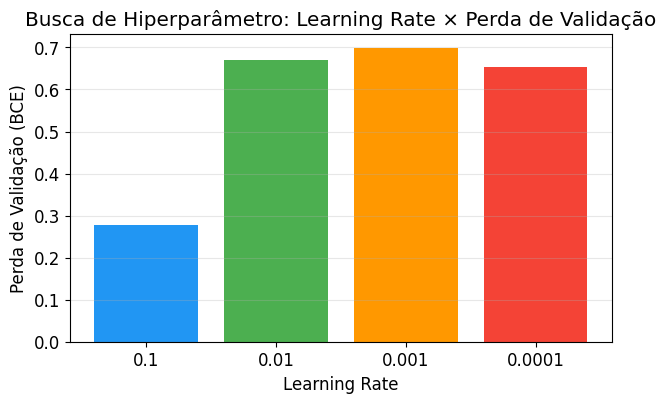

In [ ]:
# Demonstração de divisão treino/validação/teste e busca de hiperparâmetro

X_full, y_full = make_classification(                              # Gera um dataset sintético de classificação binária
    n_samples=1000, n_features=10, n_informative=5,                # 1000 amostras, 10 features no total, 5 realmente informativas
    n_redundant=2, random_state=42                                 # 2 features redundantes (combinações lineares das informativas), semente fixa
)

X_temp, X_test, y_temp, y_test = train_test_split(X_full, y_full, test_size=0.15, random_state=42)  # Separa 15% para teste (150 amostras), o restante (850) vai para X_temp
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.18, random_state=42)  # Dos 850 restantes, separa 18% para validação (~153), o resto (~697) é treino

print(f'Treino:    {X_train.shape[0]} exemplos ({100*X_train.shape[0]/1000:.0f}%)')   # Imprime quantidade e percentual de exemplos de treino
print(f'Validação: {X_val.shape[0]} exemplos ({100*X_val.shape[0]/1000:.0f}%)')       # Imprime quantidade e percentual de exemplos de validação
print(f'Teste:     {X_test.shape[0]} exemplos ({100*X_test.shape[0]/1000:.0f}%)')     # Imprime quantidade e percentual de exemplos de teste

# Busca de hiperparâmetro: qual learning rate é melhor?
scaler = StandardScaler()                                          # Cria um normalizador que vai centralizar (média 0) e escalar (desvio 1) as features
X_train_s = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)  # Ajusta o scaler nos dados de treino e transforma, convertendo para tensor float32
X_val_s   = torch.tensor(scaler.transform(X_val), dtype=torch.float32)        # Transforma a validação usando as estatísticas do treino (sem fit!), converte para tensor
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)           # Converte labels de treino para tensor e adiciona dimensão (de shape (n,) para (n,1))
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)           # Converte labels de validação para tensor com shape (n,1)

lrs = [0.1, 0.01, 0.001, 0.0001]                                 # Lista de learning rates a testar
val_losses = []                                                    # Lista vazia para armazenar a perda de validação de cada learning rate

for lr in lrs:                                                     # Itera sobre cada learning rate candidata
    model = nn.Sequential(nn.Linear(10, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())  # Cria rede: 10→16 (camada oculta com ReLU), 16→1 (saída com Sigmoid para probabilidade)
    opt = optim.SGD(model.parameters(), lr=lr)                     # Cria otimizador SGD com a learning rate atual
    loss_fn = nn.BCELoss()                                         # Define a função de perda: Binary Cross-Entropy (para classificação binária)

    for _ in range(200):                                           # Loop de treino: 200 épocas
        model.train()                                              # Coloca o modelo em modo de treino (ativa dropout/batchnorm se houver)
        opt.zero_grad()                                            # Zera os gradientes acumulados do passo anterior
        loss = loss_fn(model(X_train_s), y_train_t)                # Forward pass: calcula predições e a perda BCE no treino
        loss.backward()                                            # Backward pass: calcula os gradientes via backpropagation
        opt.step()                                                 # Atualiza os pesos na direção oposta ao gradiente (w = w - lr * grad)

    model.eval()                                                   # Coloca o modelo em modo de avaliação (desativa dropout/batchnorm)
    with torch.no_grad():                                          # Desativa o cálculo de gradientes (economiza memória e tempo)
        val_loss = loss_fn(model(X_val_s), y_val_t).item()         # Calcula a perda BCE na validação e extrai o valor escalar com .item()
    val_losses.append(val_loss)                                    # Adiciona a perda de validação à lista

plt.figure(figsize=(7, 4))                                        # Cria figura de 7x4 polegadas
plt.bar([str(lr) for lr in lrs], val_losses, color=['#2196F3','#4CAF50','#FF9800','#F44336'])  # Plota barras com a perda de cada lr, cada uma com cor diferente
plt.xlabel('Learning Rate')                                        # Rótulo do eixo X
plt.ylabel('Perda de Validação (BCE)')                             # Rótulo do eixo Y
plt.title('Busca de Hiperparâmetro: Learning Rate × Perda de Validação')  # Título do gráfico
plt.grid(True, alpha=0.3, axis='y')                               # Grade horizontal com 30% de transparência (apenas eixo Y)
melhor_lr = lrs[np.argmin(val_losses)]                             # Encontra a learning rate com menor perda de validação usando argmin
print(f'\nMelhor learning rate: {melhor_lr} (val loss = {min(val_losses):.4f})')  # Imprime a melhor lr e sua perda
plt.show()                                                         # Renderiza e exibe o gráfico de barras

---

## 4. Estimadores, Viés e Variância (~5 min)

### Estimador

Um **estimador** $\hat{\theta}_m$ é uma função dos dados que produz uma estimativa do parâmetro verdadeiro $\theta^*$:

$$\hat{\theta}_m = g(x^{(1)}, x^{(2)}, \ldots, x^{(m)})$$

### Viés

$$\text{viés}(\hat{\theta}_m) = \mathbb{E}[\hat{\theta}_m] - \theta^*$$

- **Estimador não-viesado:** $\mathbb{E}[\hat{\theta}_m] = \theta^*$
- **Estimador assintoticamente não-viesado:** $\lim_{m\to\infty} \mathbb{E}[\hat{\theta}_m] = \theta^*$

### Variância

$$\text{Var}(\hat{\theta}) = \mathbb{E}[(\hat{\theta} - \mathbb{E}[\hat{\theta}])^2]$$

### Decomposição do Erro Quadrático Médio

$$\text{MSE} = \mathbb{E}[(\hat{\theta}_m - \theta^*)^2] = \text{viés}^2 + \text{Var}(\hat{\theta}_m)$$

Este é o famoso **trade-off viés-variância**: aumentar a capacidade reduz o viés mas aumenta a variância.

### Consistência (Seção 5.4.4)

Um estimador é **consistente** se ele converge em probabilidade para o valor verdadeiro:

$$\text{plim}_{m \to \infty} \hat{\theta}_m = \theta^*$$

Consistência garante que, com dados suficientes, o estimador converge. É uma propriedade assintótica — um estimador viesado pode ser consistente se o viés desaparece com $m \to \infty$.

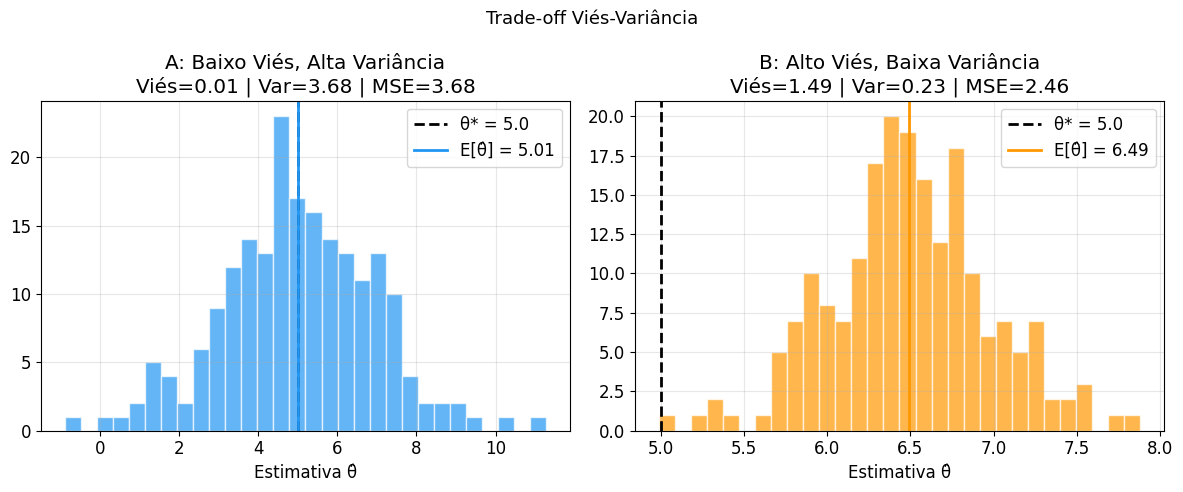

In [ ]:
# Ilustração visual do trade-off viés-variância

fig, axes = plt.subplots(1, 2, figsize=(12, 5))                   

# Simulação: estimadores com diferentes viés e variância
theta_true = 5.0                                                   # Define o valor verdadeiro do parâmetro que queremos estimar
n_amostras = 500                                                   # Número de amostras (definido mas não usado diretamente no código)
n_experimentos = 200                                               # Número de vezes que cada estimador é "rodado" (simula repetir o experimento 200 vezes)

# Estimador A: baixo viés, alta variância (modelo complexo)
est_A = theta_true + np.random.randn(n_experimentos) * 2.0        # 200 estimativas centradas em θ*=5 (viés ~0), mas com desvio padrão 2.0 (espalhadas)

# Estimador B: alto viés, baixa variância (modelo simples)
est_B = theta_true + 1.5 + np.random.randn(n_experimentos) * 0.5  # 200 estimativas centradas em 6.5 (viés de +1.5), mas com desvio padrão 0.5 (concentradas)

for ax, est, label, cor in zip(axes,                               # Itera sobre os 2 subplots, os 2 estimadores, seus labels e cores
                                [est_A, est_B],
                                ['A: Baixo Viés, Alta Variância', 'B: Alto Viés, Baixa Variância'],
                                ['#2196F3', '#FF9800']):
    vies = np.mean(est) - theta_true                               # Calcula o viés: diferença entre a média das estimativas e o valor verdadeiro
    variancia = np.var(est)                                        # Calcula a variância das estimativas (dispersão ao redor da própria média)
    mse = vies**2 + variancia                                      # Calcula o MSE pela decomposição: MSE = viés² + variância

    ax.hist(est, bins=30, color=cor, alpha=0.7, edgecolor='white') # Plota histograma das 200 estimativas com 30 bins, 70% opacidade, bordas brancas
    ax.axvline(theta_true, color='black', lw=2, ls='--', label=f'θ* = {theta_true}')  # Linha vertical preta tracejada no valor verdadeiro θ*=5
    ax.axvline(np.mean(est), color=cor, lw=2, label=f'E[θ̂] = {np.mean(est):.2f}')    # Linha vertical colorida na média das estimativas (mostra onde o estimador "mira")
    ax.set_title(f'{label}\nViés={vies:.2f} | Var={variancia:.2f} | MSE={mse:.2f}')   # Título com o label e os 3 valores numéricos calculados
    ax.set_xlabel('Estimativa θ̂')                                  # Rótulo do eixo X
    ax.legend()                                                    # Exibe a legenda com as duas linhas verticais
    ax.grid(True, alpha=0.3)                                       # Grade de fundo com 30% de transparência

plt.suptitle('Trade-off Viés-Variância', fontsize=13)              # Título geral acima dos 2 subplots
plt.tight_layout()                                                 # Ajusta espaçamento entre subplots
plt.show()                                                         # Renderiza e exibe a figura

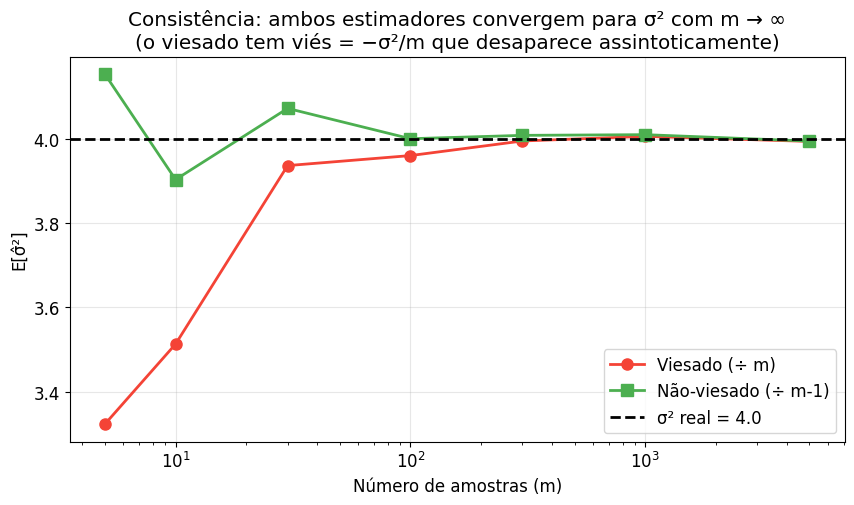

In [15]:
# Consistência: o estimador converge para θ* com m → ∞
# Exemplo: variância amostral com denominador m (viesado, mas consistente)

theta_true_var = 4.0                                               # Define a variância real da população (σ²=4, logo σ=2)
tamanhos_m = [5, 10, 30, 100, 300, 1000, 5000]                    # Lista de tamanhos de amostra a testar (de muito pequeno a grande)
n_repeticoes = 500                                                 # Número de repetições do experimento para cada tamanho (para estimar a esperança)

# Estimador viesado da variância: (1/m) Σ(x - x̄)² → viés = -σ²/m
# Estimador não-viesado: (1/(m-1)) Σ(x - x̄)²
medias_viesado = []                                                # Lista para armazenar a média do estimador viesado para cada tamanho m
medias_nao_viesado = []                                            # Lista para armazenar a média do estimador não-viesado para cada tamanho m

for m_size in tamanhos_m:                                          # Itera sobre cada tamanho de amostra
    ests_v = []                                                    # Lista temporária para as 500 estimativas viesadas com este m
    ests_nv = []                                                   # Lista temporária para as 500 estimativas não-viesadas com este m
    for _ in range(n_repeticoes):                                  # Repete o experimento 500 vezes
        amostra = np.random.normal(0, np.sqrt(theta_true_var), m_size)  # Gera m_size valores de uma normal com média 0 e desvio √4=2
        ests_v.append(np.var(amostra, ddof=0))                     # Calcula variância dividindo por m (ddof=0 → viesado), adiciona à lista
        ests_nv.append(np.var(amostra, ddof=1))                    # Calcula variância dividindo por m-1 (ddof=1 → não-viesado), adiciona à lista
    medias_viesado.append(np.mean(ests_v))                         # Média das 500 estimativas viesadas ≈ E[σ̂²_viesado] para este m
    medias_nao_viesado.append(np.mean(ests_nv))                    # Média das 500 estimativas não-viesadas ≈ E[σ̂²_não-viesado] para este m

plt.figure(figsize=(10, 5))                                       # Cria figura de 10x5 polegadas
plt.plot(tamanhos_m, medias_viesado, 'o-', color='#F44336', lw=2, ms=8, label='Viesado (÷ m)')       # Plota curva do estimador viesado (círculos vermelhos conectados)
plt.plot(tamanhos_m, medias_nao_viesado, 's-', color='#4CAF50', lw=2, ms=8, label='Não-viesado (÷ m-1)')  # Plota curva do estimador não-viesado (quadrados verdes conectados)
plt.axhline(theta_true_var, color='black', ls='--', lw=2, label=f'σ² real = {theta_true_var}')       # Linha horizontal preta tracejada no valor verdadeiro σ²=4
plt.xscale('log')                                                 # Escala logarítmica no eixo X (para visualizar melhor a faixa de 5 a 5000)
plt.xlabel('Número de amostras (m)')                               # Rótulo do eixo X
plt.ylabel('E[σ̂²]')                                               # Rótulo do eixo Y: esperança do estimador de variância
plt.title('Consistência: ambos estimadores convergem para σ² com m → ∞\n(o viesado tem viés = −σ²/m que desaparece assintoticamente)')  # Título com explicação do fenômeno
plt.legend()                                                       # Exibe a legenda com as 3 entradas
plt.grid(True, alpha=0.3)                                         # Grade de fundo com 30% de transparência
plt.show()                                                         # Renderiza e exibe o gráfico

---

## 5. Estimação por Máxima Verossimilhança (MLE) (~5 min)

A maioria dos algoritmos de ML pode ser interpretada como **maximização da verossimilhança** dos dados observados.

Dado um dataset $\mathcal{D} = \{x^{(1)}, \ldots, x^{(m)}\}$ i.i.d. segundo $p_{dados}$, o estimador de máxima verossimilhança é:

$$\theta_{ML} = \arg\max_{\theta} \prod_{i=1}^{m} p_{modelo}(x^{(i)}; \theta)$$

Na prática, trabalhamos com o **log-likelihood** (mais estável numericamente):

$$\theta_{ML} = \arg\max_{\theta} \sum_{i=1}^{m} \log p_{modelo}(x^{(i)}; \theta)$$

### Conexão fundamental: MLE ↔ KL Divergence ↔ Cross-Entropy (Seção 5.5.1)

O livro mostra que maximizar o log-likelihood é **equivalente** a minimizar a divergência KL entre a distribuição empírica $\hat{p}_{dados}$ e o modelo $p_{modelo}$:

$$D_{KL}(\hat{p}_{dados} \| p_{modelo}) = \underbrace{\mathbb{E}_{x \sim \hat{p}}[\log \hat{p}(x)]}_{\text{entropia (constante)}} - \underbrace{\mathbb{E}_{x \sim \hat{p}}[\log p_{modelo}(x; \theta)]}_{\text{este é o neg. log-likelihood!}}$$

Como o primeiro termo é constante (não depende de $\theta$), minimizar $D_{KL}$ é equivalente a maximizar o log-likelihood, que por sua vez é equivalente a **minimizar a cross-entropy**:

$$H(\hat{p}, p_{modelo}) = -\mathbb{E}_{x \sim \hat{p}}[\log p_{modelo}(x; \theta)]$$

> 💡 **Isso explica por que cross-entropy é a loss padrão em classificação:** ela é simplesmente o MLE para modelos de Bernoulli/Categorical!

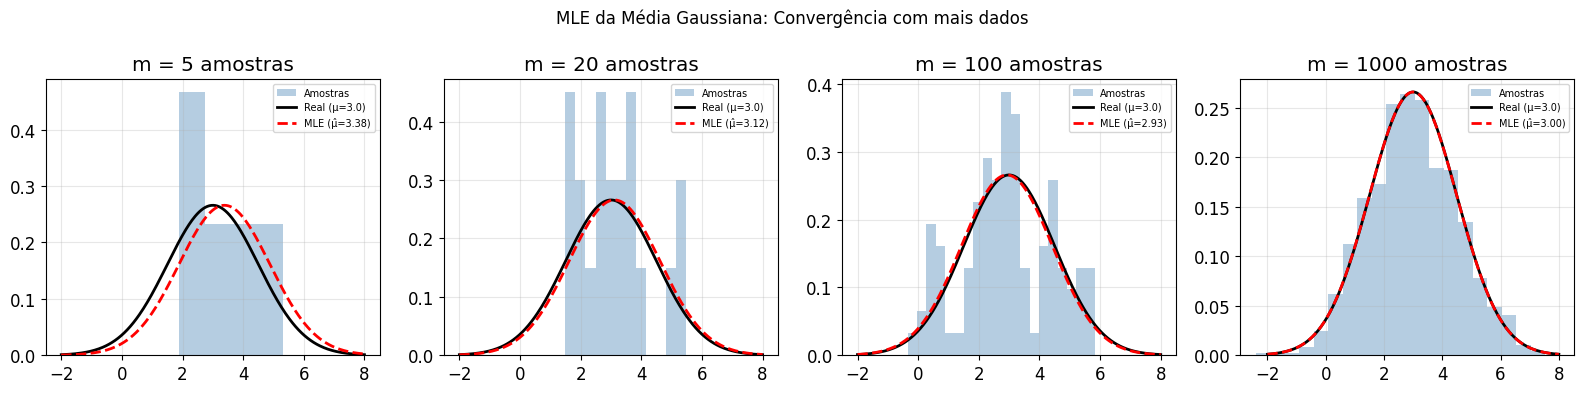

In [16]:
# MLE: estimando a média de uma Gaussiana
# O MLE para a média de N(μ, σ²) com σ² conhecido é simplesmente a média amostral

mu_true = 3.0                                                     # Define a média real da distribuição gaussiana
sigma = 1.5                                                        # Define o desvio padrão real (conhecido e fixo)
tamanhos = [5, 20, 100, 1000]                                     # Lista de tamanhos de amostra para demonstrar a convergência

fig, axes = plt.subplots(1, 4, figsize=(16, 4))                   # Cria figura com 4 subplots lado a lado (16x4 polegadas)

for ax, m in zip(axes, tamanhos):                                  # Itera sobre cada subplot e cada tamanho de amostra
    amostras = np.random.normal(mu_true, sigma, m)                 # Gera m amostras de uma gaussiana N(3.0, 1.5²)
    mu_mle = np.mean(amostras)                                     # Calcula o MLE da média: é simplesmente a média aritmética das amostras

    x_range = np.linspace(mu_true - 5, mu_true + 5, 300)          # Cria 300 pontos de -2 a 8 para desenhar as curvas gaussianas
    p_true = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_range - mu_true)/sigma)**2)  # Calcula a PDF da gaussiana real N(3.0, 1.5²) manualmente
    p_mle  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x_range - mu_mle)/sigma)**2)   # Calcula a PDF da gaussiana estimada N(μ̂_MLE, 1.5²) com a média estimada

    ax.hist(amostras, bins=min(20, m//2+2), density=True, alpha=0.4, color='steelblue', label='Amostras')  # Histograma normalizado (density=True) das amostras, bins adaptativo: mín entre 20 e m/2+2
    ax.plot(x_range, p_true, 'k-', lw=2, label=f'Real (μ={mu_true})')    # Curva da gaussiana real em preto sólido
    ax.plot(x_range, p_mle, 'r--', lw=2, label=f'MLE (μ̂={mu_mle:.2f})') # Curva da gaussiana estimada em vermelho tracejado
    ax.set_title(f'm = {m} amostras')                              # Título mostrando o número de amostras usado
    ax.legend(fontsize=7)                                          # Exibe legenda com fonte tamanho 7 (pequena para caber)
    ax.grid(True, alpha=0.3)                                       # Grade de fundo com 30% de transparência

plt.suptitle('MLE da Média Gaussiana: Convergência com mais dados', fontsize=12)  # Título geral acima dos 4 subplots
plt.tight_layout()                                                 # Ajusta espaçamento entre subplots
plt.show()                                                         # Renderiza e exibe a figura

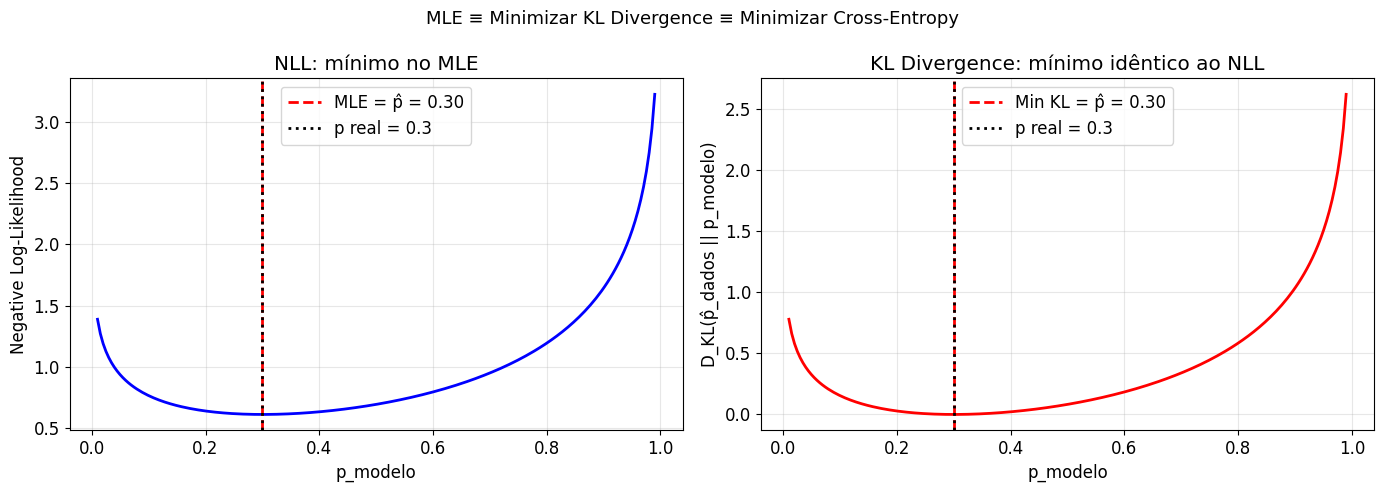

p real = 0.30
p empírico (MLE) = 0.30
NLL no MLE = 0.6109


In [18]:
# Demonstração: MLE minimiza a KL divergence entre dados e modelo
# Exemplo: estimando p de uma Bernoulli

from scipy.special import rel_entr                                 

p_real = 0.3                                                       # Define a probabilidade real de sucesso da Bernoulli
n_amostras_ce = 100                                                # Define o número de amostras a gerar
np.random.seed(42)                                                 # Fixa a semente para reprodutibilidade
dados = np.random.binomial(1, p_real, n_amostras_ce)              # Gera 100 amostras de Bernoulli (0 ou 1) com p=0.3
p_empirico = np.mean(dados)                                        # Calcula a frequência observada de sucessos (= MLE de p para Bernoulli)

p_modelo_range = np.linspace(0.01, 0.99, 200)                     # Cria 200 valores candidatos de p entre 0.01 e 0.99 (evita 0 e 1 para não estourar o log)

# Negative log-likelihood (normalizado)
nll = -(p_empirico * np.log(p_modelo_range) + (1 - p_empirico) * np.log(1 - p_modelo_range))  # Calcula a NLL da Bernoulli: -[p̂·log(p) + (1-p̂)·log(1-p)] para cada p candidato

# KL divergence: D_KL(p_emp || p_modelo)
kl = p_empirico * np.log(p_empirico / p_modelo_range) + (1 - p_empirico) * np.log((1 - p_empirico) / (1 - p_modelo_range))  # Calcula KL entre distribuição empírica e cada p candidato

fig, axes = plt.subplots(1, 2, figsize=(14, 5))                   # Cria figura com 2 subplots lado a lado (14x5 polegadas)

axes[0].plot(p_modelo_range, nll, 'b-', lw=2)                     # Plota a curva de NLL em azul no subplot esquerdo
axes[0].axvline(p_empirico, color='red', ls='--', lw=2, label=f'MLE = p̂ = {p_empirico:.2f}')  # Linha vertical vermelha no MLE (ponto de mínimo da NLL)
axes[0].axvline(p_real, color='black', ls=':', lw=2, label=f'p real = {p_real}')               # Linha vertical preta pontilhada no p real
axes[0].set_xlabel('p_modelo')                                     # Rótulo do eixo X: o parâmetro p do modelo
axes[0].set_ylabel('Negative Log-Likelihood')                      # Rótulo do eixo Y
axes[0].set_title('NLL: mínimo no MLE')                            # Título do subplot esquerdo
axes[0].legend()                                                   # Exibe a legenda
axes[0].grid(True, alpha=0.3)                                     # Grade com 30% de transparência

axes[1].plot(p_modelo_range, kl, 'r-', lw=2)                      # Plota a curva de KL divergence em vermelho no subplot direito
axes[1].axvline(p_empirico, color='red', ls='--', lw=2, label=f'Min KL = p̂ = {p_empirico:.2f}')  # Linha vertical no mínimo da KL (coincide com o MLE)
axes[1].axvline(p_real, color='black', ls=':', lw=2, label=f'p real = {p_real}')                   # Linha vertical no p real
axes[1].set_xlabel('p_modelo')                                     # Rótulo do eixo X
axes[1].set_ylabel('D_KL(p̂_dados || p_modelo)')                   # Rótulo do eixo Y: KL da distribuição empírica para o modelo
axes[1].set_title('KL Divergence: mínimo idêntico ao NLL')         # Título do subplot direito
axes[1].legend()                                                   # Exibe a legenda
axes[1].grid(True, alpha=0.3)                                     # Grade com 30% de transparência

plt.suptitle('MLE ≡ Minimizar KL Divergence ≡ Minimizar Cross-Entropy', fontsize=13)  # Título geral mostrando a equivalência dos três critérios
plt.tight_layout()                                                 # Ajusta espaçamento
plt.show()                                                         # Renderiza e exibe

print(f'p real = {p_real:.2f}')                                    # Imprime o p verdadeiro
print(f'p empírico (MLE) = {p_empirico:.2f}')                     # Imprime o MLE (frequência observada)
print(f'NLL no MLE = {-(p_empirico * np.log(p_empirico) + (1-p_empirico) * np.log(1-p_empirico)):.4f}')  # Calcula e imprime a NLL avaliada no ponto ótimo (= entropia da distribuição empírica)

---

## 6. Estatística Bayesiana e MAP (~5 min)

Na visão bayesiana, $\theta$ não é um valor fixo desconhecido, mas uma **variável aleatória** com distribuição de probabilidade.

### Teorema de Bayes

$$p(\theta \mid \mathcal{D}) = \frac{p(\mathcal{D} \mid \theta) \cdot p(\theta)}{p(\mathcal{D})}$$

| Termo | Nome | Significado |
|-------|------|-------------|
| $p(\theta)$ | Prior | Crença sobre θ *antes* de ver os dados |
| $p(\mathcal{D} \mid \theta)$ | Verossimilhança | Probabilidade dos dados dado θ |
| $p(\theta \mid \mathcal{D})$ | Posterior | Crença *atualizada* após ver os dados |
| $p(\mathcal{D})$ | Evidência | Constante de normalização |

### MAP: Maximum A Posteriori (Seção 5.6.1)

$$\theta_{MAP} = \arg\max_\theta [\log p(\mathcal{D}|\theta) + \log p(\theta)]$$

Se a prior é **gaussiana** $p(\theta) = \mathcal{N}(0, \frac{1}{\lambda}I)$, então:

$$\log p(\theta) = -\frac{\lambda}{2} \|\theta\|_2^2 + \text{const.}$$

Portanto, **MAP com prior gaussiana = MLE + regularização L2 (weight decay)!**

Isso mostra que a regularização tem uma **interpretação bayesiana**: estamos incorporando uma crença a priori de que os pesos devem ser pequenos.

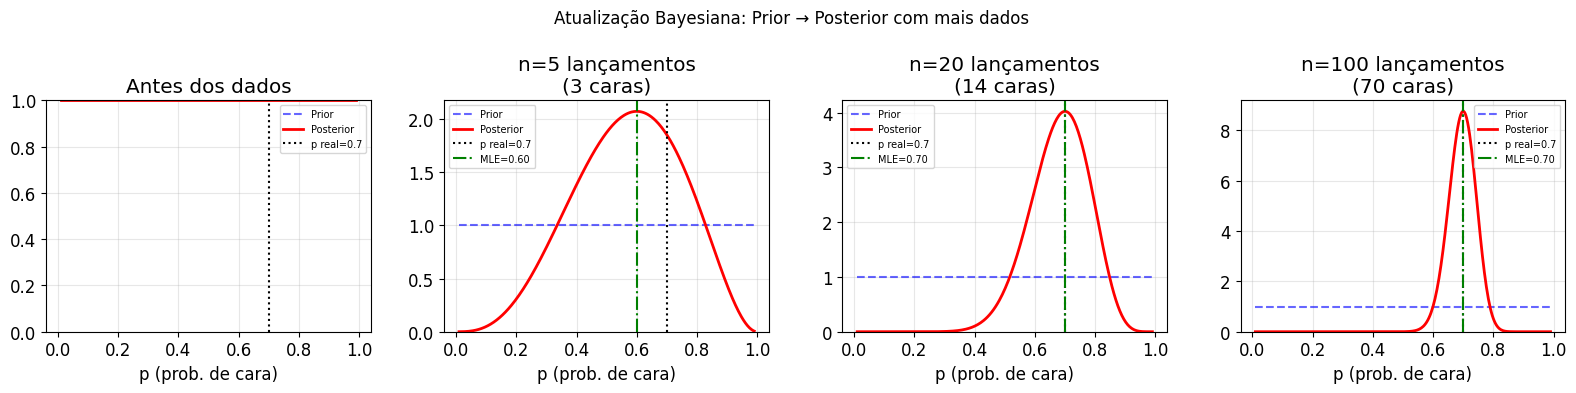

In [ ]:
# Atualização Bayesiana: estimando p (prob. de cara em uma moeda)
# Prior: Beta(α, β) — conjugado para Bernoulli
# Posterior: Beta(α + k, β + n - k)

from scipy.stats import beta as beta_dist                         # Importa a distribuição Beta do scipy, renomeada para evitar conflito com a função built-in

p_true = 0.7                                                      # Define a probabilidade real de cara (moeda viciada)
p_range = np.linspace(0.01, 0.99, 300)                            # Cria 300 pontos entre 0.01 e 0.99 para plotar as PDFs

# Prior: uniforme Beta(1, 1) — sem conhecimento prévio
alpha_prior, beta_prior = 1, 1                                    # Beta(1,1) é equivalente a uma distribuição uniforme em [0,1] — prior não-informativo

sequencias = [0, 5, 20, 100]                                      # Número de lançamentos a observar em cada subplot (0 = antes de ver dados)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))                   # Cria figura com 4 subplots lado a lado (16x4 polegadas)

np.random.seed(42)                                                # Fixa semente para reprodutibilidade
lancamentos = np.random.binomial(1, p_true, max(sequencias))      # Gera 100 lançamentos de moeda (0=coroa, 1=cara) com p=0.7 de uma vez

for ax, n in zip(axes, sequencias):                                # Itera sobre cada subplot e cada quantidade de observações
    k = np.sum(lancamentos[:n]) if n > 0 else 0                   # Conta o número de caras nos primeiros n lançamentos (0 se n=0)
    alpha_post = alpha_prior + k                                   # Atualiza α da posterior: α_post = α_prior + número de caras
    beta_post  = beta_prior + (n - k)                              # Atualiza β da posterior: β_post = β_prior + número de coroas

    prior = beta_dist.pdf(p_range, alpha_prior, beta_prior)        # Calcula a PDF da prior Beta(1,1) nos 300 pontos (será uma linha reta em 1.0)
    posterior = beta_dist.pdf(p_range, alpha_post, beta_post)      # Calcula a PDF da posterior Beta(α_post, β_post) nos 300 pontos

    ax.plot(p_range, prior, 'b--', lw=1.5, alpha=0.6, label='Prior')              # Plota a prior em azul tracejado (60% opacidade)
    ax.plot(p_range, posterior, 'r-', lw=2, label='Posterior')                     # Plota a posterior em vermelho sólido
    ax.axvline(p_true, color='black', ls=':', lw=1.5, label=f'p real={p_true}')   # Linha vertical preta pontilhada no p verdadeiro
    if n > 0:                                                      # Se já observou dados...
        ax.axvline(k/n, color='green', ls='-.', lw=1.5, label=f'MLE={k/n:.2f}')  # Linha vertical verde no MLE (frequência observada k/n)
    ax.set_title(f'n={n} lançamentos\n({k} caras)' if n > 0 else 'Antes dos dados')  # Título: mostra n e k, ou "Antes dos dados" se n=0
    ax.set_xlabel('p (prob. de cara)')                             # Rótulo do eixo X
    ax.legend(fontsize=7)                                          # Exibe legenda com fonte tamanho 7
    ax.set_ylim(0, None)                                           # Fixa limite inferior do eixo Y em 0, superior automático
    ax.grid(True, alpha=0.3)                                       # Grade com 30% de transparência

plt.suptitle('Atualização Bayesiana: Prior → Posterior com mais dados', fontsize=12)  # Título geral
plt.tight_layout()                                                 # Ajusta espaçamento
plt.show()                                                         # Renderiza e exibe

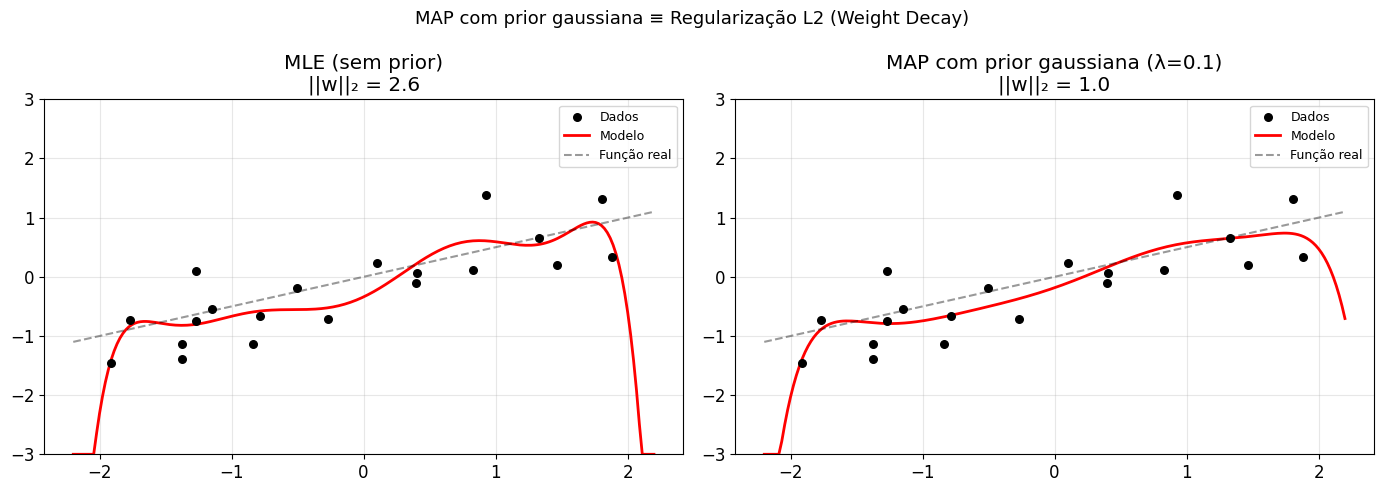

Norma dos pesos MLE: 2.63
Norma dos pesos MAP: 0.97
→ A prior gaussiana "encolhe" os pesos, prevenindo overfitting


In [19]:
# MAP com prior gaussiana = MLE + Regularização L2
# Demonstração: regressão com pesos grandes vs. MAP com prior

np.random.seed(42)                                                 # Fixa a semente para reprodutibilidade
X_map = np.sort(np.random.uniform(-2, 2, 20))                     # Gera 20 valores uniformes entre -2 e 2, ordenados crescentemente
y_map = 0.5 * X_map + np.random.randn(20) * 0.5                   # Gera y = 0.5x + ruído gaussiano (desvio 0.5) — função real é uma reta simples

grau_map = 8                                                       # Define grau do polinômio (alto para provocar overfitting no MLE)
V_map = np.vstack([X_map**i for i in range(grau_map+1)]).T        # Constrói a matriz de Vandermonde (20x9): colunas [x⁰, x¹, ..., x⁸]

# MLE puro: minimiza ||Vw - y||²
w_mle = np.linalg.lstsq(V_map, y_map, rcond=None)[0]             # Resolve por mínimos quadrados (pseudo-inversa), retorna os 9 coeficientes ótimos sem regularização

# MAP com prior gaussiana N(0, 1/λ): minimiza ||Vw - y||² + λ||w||²
lambda_map = 0.1                                                   # Define a intensidade da regularização (equivale à precisão da prior gaussiana)
w_map = np.linalg.solve(V_map.T @ V_map + lambda_map * np.eye(grau_map+1), V_map.T @ y_map)  # Resolve a equação Ridge: (VᵀV + λI)w = Vᵀy — equivalente ao MAP com prior N(0, 1/λ)

X_plot_map = np.linspace(-2.2, 2.2, 200)                          # Cria 200 pontos para plotagem suave, um pouco além do range dos dados
V_plot_map = np.vstack([X_plot_map**i for i in range(grau_map+1)]).T  # Constrói a Vandermonde de plotagem (200x9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))                   # Cria figura com 2 subplots lado a lado (14x5 polegadas)

for ax, w, titulo in zip(axes, [w_mle, w_map],                    # Itera sobre subplots, vetores de pesos e títulos
                          [f'MLE (sem prior)\n||w||₂ = {np.linalg.norm(w_mle):.1f}',          # Título do MLE com norma dos pesos
                           f'MAP com prior gaussiana (λ={lambda_map})\n||w||₂ = {np.linalg.norm(w_map):.1f}']):  # Título do MAP com norma dos pesos
    y_plot_map = V_plot_map @ w                                    # Calcula as predições: ŷ = V_plot · w (multiplicação matricial)
    ax.scatter(X_map, y_map, color='black', s=30, zorder=5, label='Dados')                    # Plota os 20 pontos de treino em preto
    ax.plot(X_plot_map, np.clip(y_plot_map, -3, 3), 'r-', lw=2, label='Modelo')               # Plota a curva do modelo em vermelho, clipada entre -3 e 3
    ax.plot(X_plot_map, 0.5 * X_plot_map, 'k--', alpha=0.4, label='Função real')              # Plota a reta real y=0.5x em preto tracejado
    ax.set_ylim(-3, 3)                                             # Fixa limites do eixo Y para comparação visual
    ax.set_title(titulo)                                           # Define o título (MLE ou MAP com suas normas)
    ax.legend(fontsize=9)                                          # Exibe legenda com fonte tamanho 9
    ax.grid(True, alpha=0.3)                                       # Grade com 30% de transparência

plt.suptitle('MAP com prior gaussiana ≡ Regularização L2 (Weight Decay)', fontsize=13)  # Título geral mostrando a equivalência MAP↔L2
plt.tight_layout()                                                 # Ajusta espaçamento
plt.show()                                                         # Renderiza e exibe

print(f'Norma dos pesos MLE: {np.linalg.norm(w_mle):.2f}')        # Imprime a norma L2 dos pesos MLE (tipicamente grande)
print(f'Norma dos pesos MAP: {np.linalg.norm(w_map):.2f}')        # Imprime a norma L2 dos pesos MAP (tipicamente bem menor)
print(f'→ A prior gaussiana "encolhe" os pesos, prevenindo overfitting')  # Mensagem explicativa sobre o efeito da regularização

---

## 7 e 8. Algoritmos Supervisionados e Não Supervisionados (~5 min)

### Supervisionado (Seção 5.7)
O dataset contém pares $(x^{(i)}, y^{(i)})$. O objetivo é aprender $p(y|x)$ ou uma função $f: x \mapsto y$.

- **Regressão:** $y \in \mathbb{R}$ (valor contínuo)
- **Classificação:** $y \in \{1, \ldots, K\}$ (classe discreta)

**Algoritmos clássicos discutidos no livro:**
- **k-Nearest Neighbors (k-NN):** classifica pelo voto dos $k$ vizinhos mais próximos — baseado puramente em suavidade local
- **Support Vector Machine (SVM):** encontra o hiperplano de máxima margem usando um kernel
- **Árvores de Decisão:** particiona o espaço em regiões retangulares

> 💡 Esses algoritmos dependem da suposição de **suavidade local** — funcionam bem em baixas dimensões, mas sofrem com a maldição da dimensionalidade (Seção 11).

### Não Supervisionado (Seção 5.8)
O dataset contém apenas $\{x^{(i)}\}$, sem rótulos. O objetivo é aprender a estrutura de $p(x)$.

- **Clustering** (ex: K-Means): agrupa exemplos similares
- **Redução de dimensionalidade** (ex: PCA): extrai representações compactas
- **Modelos generativos** (ex: VAE, GAN): aprendem a gerar novos exemplos

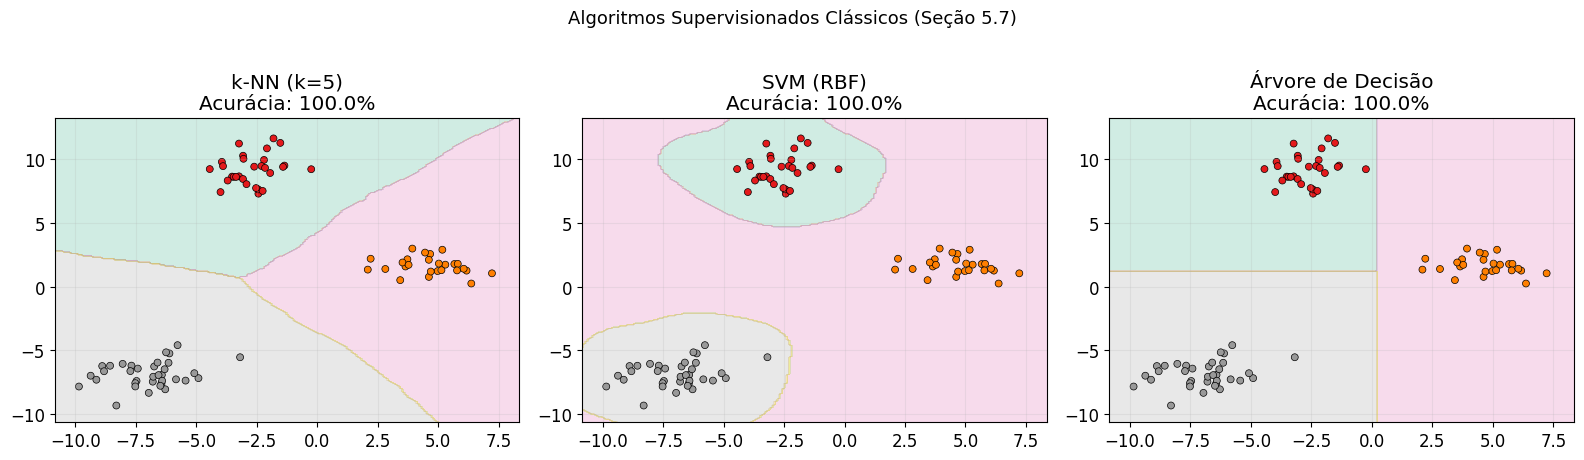

In [29]:
# Comparação de algoritmos supervisionados clássicos (Seção 5.7)
from sklearn.neighbors import KNeighborsClassifier                 # Importa o classificador k-Nearest Neighbors
from sklearn.svm import SVC                                        # Importa o Support Vector Classifier
from sklearn.tree import DecisionTreeClassifier                    # Importa o classificador Árvore de Decisão

X_data, y_data = make_blobs(n_samples=300, centers=3, cluster_std=1.2, random_state=42)  # Gera 300 pontos em 3 clusters gaussianos com desvio 1.2 (classificação com 3 classes)
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_data, y_data, test_size=0.3, random_state=42)  # Separa 70% treino (210) e 30% teste (90)

modelos_sk = {                                                     # Dicionário com 3 modelos a comparar
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),            # k-NN com 5 vizinhos: classifica pelo voto majoritário dos 5 pontos mais próximos
    'SVM (RBF)': SVC(kernel='rbf', gamma='auto'),                 # SVM com kernel RBF (gaussiano): encontra fronteira não-linear no espaço transformado
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=5, random_state=42),  # Árvore com profundidade máx. 5: faz splits retangulares no espaço de features
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))                 # Cria figura com 3 subplots lado a lado (16x4.5 polegadas)
h = 0.1                                                            # Define o passo da grade para o contour plot (resolução da fronteira de decisão)
x_min_s, x_max_s = X_data[:,0].min()-1, X_data[:,0].max()+1       # Calcula limites do eixo X com margem de 1 unidade
y_min_s, y_max_s = X_data[:,1].min()-1, X_data[:,1].max()+1       # Calcula limites do eixo Y com margem de 1 unidade
xx_s, yy_s = np.meshgrid(np.arange(x_min_s, x_max_s, h), np.arange(y_min_s, y_max_s, h))  # Cria grade 2D cobrindo todo o espaço (para classificar cada pixel)

for ax, (nome, clf) in zip(axes, modelos_sk.items()):              # Itera sobre subplots e pares (nome, classificador)
    clf.fit(X_tr_s, y_tr_s)                                        # Treina o classificador nos dados de treino
    acc_s = clf.score(X_te_s, y_te_s)                              # Calcula a acurácia no conjunto de teste (proporção de acertos)
    Z_s = clf.predict(np.c_[xx_s.ravel(), yy_s.ravel()]).reshape(xx_s.shape)  # Classifica cada ponto da grade: achata a grade, prediz, e reshape de volta para 2D

    ax.contourf(xx_s, yy_s, Z_s, alpha=0.3, cmap='Set2')          # Plota as regiões de decisão como áreas coloridas (30% opacidade, paleta Set2)
    ax.scatter(X_te_s[:,0], X_te_s[:,1], c=y_te_s, cmap='Set1', s=25, edgecolors='k', linewidth=0.5)  # Plota os pontos de teste coloridos pela classe real, com borda preta
    ax.set_title(f'{nome}\nAcurácia: {acc_s*100:.1f}%')           # Título com o nome do modelo e a acurácia em porcentagem
    ax.grid(True, alpha=0.2)                                       # Grade com 20% de transparência

plt.suptitle('Algoritmos Supervisionados Clássicos (Seção 5.7)', fontsize=13, y=1.02)  # Título geral acima dos subplots
plt.tight_layout()                                                 # Ajusta espaçamento
plt.show()                                                         # Renderiza e exibe

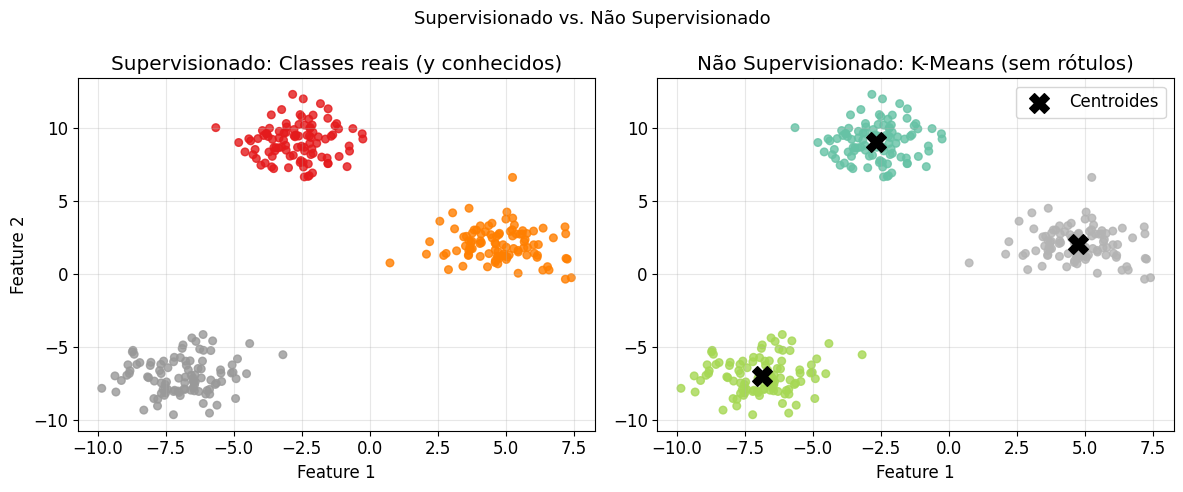

In [30]:
# Não Supervisionado: K-Means + PCA
from sklearn.cluster import KMeans                                 # Importa o algoritmo de clusterização K-Means
from sklearn.decomposition import PCA                              # Importa o PCA (importado mas não usado neste trecho)

X_data_us, y_data_us = make_blobs(n_samples=300, centers=3, cluster_std=1.2, random_state=42)  # Gera 300 pontos em 3 clusters gaussianos (mesmos dados do exemplo anterior)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)         # Cria o modelo K-Means com 3 clusters, semente fixa, e 10 inicializações diferentes (escolhe a melhor)
y_cluster = kmeans.fit_predict(X_data_us)                          # Treina o K-Means nos dados (sem usar rótulos) e retorna o cluster atribuído a cada ponto

fig, axes = plt.subplots(1, 2, figsize=(12, 5))                   # Cria figura com 2 subplots lado a lado (12x5 polegadas)

# Supervisionado: usa os rótulos reais
scatter1 = axes[0].scatter(X_data_us[:, 0], X_data_us[:, 1], c=y_data_us, cmap='Set1', s=30, alpha=0.8)  # Plota os pontos coloridos pelas classes reais (y_data_us) com paleta Set1
axes[0].set_title('Supervisionado: Classes reais (y conhecidos)')  # Título indicando que aqui os rótulos verdadeiros são usados
axes[0].set_xlabel('Feature 1')                                    # Rótulo do eixo X
axes[0].set_ylabel('Feature 2')                                    # Rótulo do eixo Y
axes[0].grid(True, alpha=0.3)                                     # Grade com 30% de transparência

# Não supervisionado: descobre clusters sem rótulos
scatter2 = axes[1].scatter(X_data_us[:, 0], X_data_us[:, 1], c=y_cluster, cmap='Set2', s=30, alpha=0.8)  # Plota os pontos coloridos pelos clusters descobertos pelo K-Means (paleta Set2)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],  # Plota os 3 centroides (médias de cada cluster)
                marker='X', s=200, c='black', zorder=5, label='Centroides')    # Marcador X preto, tamanho 200, acima dos outros pontos
axes[1].set_title('Não Supervisionado: K-Means (sem rótulos)')     # Título indicando que nenhum rótulo foi usado
axes[1].set_xlabel('Feature 1')                                    # Rótulo do eixo X
axes[1].legend()                                                   # Exibe legenda (mostra "Centroides")
axes[1].grid(True, alpha=0.3)                                     # Grade com 30% de transparência

plt.suptitle('Supervisionado vs. Não Supervisionado', fontsize=13) # Título geral comparando as duas abordagens
plt.tight_layout()                                                 # Ajusta espaçamento
plt.show()                                                         # Renderiza e exibe

---

## 9. Gradiente Descendente Estocástico (SGD) (~5 min)

A maioria dos algoritmos de deep learning usa **otimização baseada em gradiente**.

### Gradiente Descendente (Batch)

Atualiza os parâmetros usando o gradiente calculado sobre **todo o dataset**:

$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta \mathcal{L}(\theta; \mathcal{D})$$

**Problema:** muito lento para datasets grandes.

### SGD — Gradiente Descendente Estocástico

Atualiza os parâmetros usando o gradiente calculado sobre **um exemplo (ou mini-batch)**:

$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta \mathcal{L}(\theta; x^{(i)}, y^{(i)})$$

| Variante | Exemplos por atualização | Característica |
|----------|--------------------------|----------------|
| Batch GD | Todos ($m$) | Estável, mas lento |
| SGD puro | 1 | Rápido, mas ruidoso |
| Mini-batch SGD | $b \in [32, 512]$ | Equilíbrio prático |

O **ruído** do SGD tem efeito regularizador e ajuda a escapar de mínimos locais rasos.

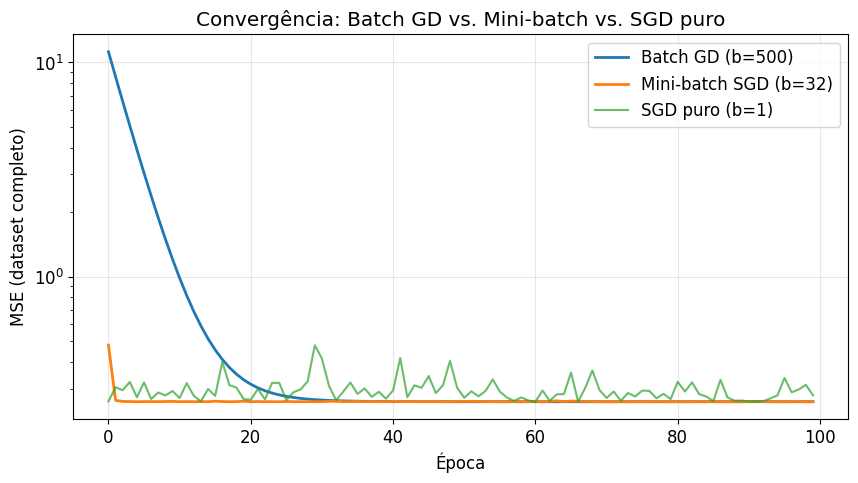

In [33]:
# Comparação: Batch GD vs. Mini-batch SGD vs. SGD puro
# Tarefa: regressão linear simples

X_reg = torch.linspace(-2, 2, 500).unsqueeze(1)                   # Cria 500 valores de -2 a 2 e adiciona dimensão para shape (500,1) — os inputs
y_reg = 3 * X_reg + 1.5 + torch.randn_like(X_reg) * 0.5          # Gera y = 3x + 1.5 + ruído gaussiano (desvio 0.5) — função real com ruído

def treinar(X, y, batch_size, n_epochs=100, lr=0.05):             # Define função de treino parametrizada pelo tamanho do batch
    model = nn.Linear(1, 1)                                        # Cria modelo linear: ŷ = w*x + b (1 entrada, 1 saída)
    nn.init.constant_(model.weight, 0.0)                           # Inicializa peso w=0 (mesmo ponto de partida para todos os métodos)
    nn.init.constant_(model.bias, 0.0)                             # Inicializa bias b=0
    opt = optim.SGD(model.parameters(), lr=lr)                     # Cria otimizador SGD com learning rate 0.05
    loss_fn = nn.MSELoss()                                         # Define a função de perda: erro quadrático médio
    historico = []                                                  # Lista para armazenar a perda total ao final de cada época

    m = X.shape[0]                                                 # Número total de amostras (500)
    for epoch in range(n_epochs):                                  # Loop sobre as 100 épocas
        perm = torch.randperm(m)                                   # Gera uma permutação aleatória dos índices (embaralha os dados a cada época)
        X_s, y_s = X[perm], y[perm]                                # Reordena X e y de acordo com a permutação
        for i in range(0, m, batch_size):                          # Itera em passos de batch_size sobre os dados embaralhados
            Xb = X_s[i:i+batch_size]                               # Seleciona o mini-batch de inputs (fatia de tamanho batch_size)
            yb = y_s[i:i+batch_size]                               # Seleciona o mini-batch de targets correspondente
            opt.zero_grad()                                        # Zera os gradientes acumulados
            loss = loss_fn(model(Xb), yb)                          # Forward pass: calcula MSE no mini-batch
            loss.backward()                                        # Backward pass: calcula gradientes
            opt.step()                                             # Atualiza pesos: w = w - lr * grad
        with torch.no_grad():                                      # Desativa gradientes para avaliação (economia de memória)
            historico.append(loss_fn(model(X), y).item())          # Calcula e registra a perda no dataset completo ao final da época
    return historico                                                # Retorna a lista de perdas por época

h_batch   = treinar(X_reg, y_reg, batch_size=500)                 # Treina com Batch GD: batch=500 (todos os dados de uma vez, 1 update por época)
h_mini    = treinar(X_reg, y_reg, batch_size=32)                  # Treina com Mini-batch SGD: batch=32 (~16 updates por época)
h_sgd     = treinar(X_reg, y_reg, batch_size=1)                   # Treina com SGD puro: batch=1 (500 updates por época, 1 amostra por vez)

plt.figure(figsize=(10, 5))                                       # Cria figura de 10x5 polegadas
plt.plot(h_batch, label='Batch GD (b=500)', lw=2)                 # Plota curva de convergência do Batch GD
plt.plot(h_mini,  label='Mini-batch SGD (b=32)', lw=2)            # Plota curva de convergência do Mini-batch
plt.plot(h_sgd,   label='SGD puro (b=1)', lw=1.5, alpha=0.7)     # Plota curva do SGD puro (mais fina e transparente pois é ruidosa)
plt.xlabel('Época')                                                # Rótulo do eixo X
plt.ylabel('MSE (dataset completo)')                               # Rótulo do eixo Y: perda avaliada no dataset inteiro
plt.title('Convergência: Batch GD vs. Mini-batch vs. SGD puro')   # Título do gráfico
plt.legend()                                                       # Exibe legenda com os 3 métodos
plt.yscale('log')                                                  # Escala logarítmica no eixo Y (para visualizar diferenças em ordens de grandeza)
plt.grid(True, alpha=0.3)                                         # Grade com 30% de transparência
plt.show()                                                         # Renderiza e exibe

---

## 10. Construindo um Algoritmo de Aprendizado de Máquina (~5 min)

Goodfellow aponta que praticamente todos os algoritmos de deep learning combinam:

1. **Uma especificação de dataset** → Seção 2
2. **Uma função de custo** (loss) → Seções 5–6 (viés-variância, MLE, cross-entropy)
3. **Um procedimento de otimização** → Seção 9 (SGD)
4. **Um modelo** → Seção 3 (capacidade) + Seção 8 (tipos de algoritmos)

A **regularização** (Seção 3) e a perspectiva **bayesiana** (Seção 7) modificam a loss, enquanto os **hiperparâmetros** (Seção 4) controlam todos os componentes.

### Exemplo completo: Classificação Binária com MLP em PyTorch

Vamos construir do zero um pipeline completo, seguindo exatamente essa estrutura.

In [38]:
# ============================================================
# Pipeline completo de ML em PyTorch
# ============================================================

# --- 1. DATASET ---
X_np, y_np = make_classification(                                  # Gera dataset sintético de classificação binária
    n_samples=800, n_features=2, n_informative=2,                  # 800 amostras, 2 features, ambas informativas (úteis para separar classes)
    n_redundant=0, n_clusters_per_class=1, random_state=42         # 0 features redundantes, 1 cluster por classe (classes compactas), semente fixa
)

scaler = StandardScaler()                                          # Cria normalizador que centraliza (média 0) e escala (desvio 1)
X_np = scaler.fit_transform(X_np)                                 # Ajusta o scaler nos dados e transforma de uma vez (normaliza as 2 features)

X_tr, X_te, y_tr, y_te = train_test_split(X_np, y_np, test_size=0.2, random_state=42)  # Separa 80% treino (640) e 20% teste (160)

X_train_t = torch.tensor(X_tr, dtype=torch.float32)               # Converte X de treino de NumPy para tensor PyTorch float32
y_train_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)  # Converte y de treino para tensor e adiciona dimensão: (640,) → (640,1)
X_test_t  = torch.tensor(X_te, dtype=torch.float32)               # Converte X de teste para tensor float32
y_test_t  = torch.tensor(y_te, dtype=torch.float32).unsqueeze(1)  # Converte y de teste para tensor com shape (160,1)

# --- 2. MODELO ---
class MLP(nn.Module):                                              # Define uma classe MLP que herda de nn.Module (base de todos os modelos PyTorch)
    def __init__(self):                                            # Construtor: define a arquitetura da rede
        super().__init__()                                         # Chama o construtor da classe pai (nn.Module) — obrigatório
        self.rede = nn.Sequential(                                 # Define a rede como sequência de camadas (executa em ordem)
            nn.Linear(2, 32),                                      # Camada 1: 2 entradas → 32 neurônios (2*32 + 32 = 96 parâmetros: pesos + biases)
            nn.ReLU(),                                             # Ativação ReLU: max(0, x) — introduz não-linearidade
            nn.Linear(32, 16),                                     # Camada 2: 32 → 16 neurônios (32*16 + 16 = 528 parâmetros)
            nn.ReLU(),                                             # Ativação ReLU novamente
            nn.Linear(16, 1),                                      # Camada 3: 16 → 1 saída (16*1 + 1 = 17 parâmetros)
            nn.Sigmoid()                                           # Ativação Sigmoid: comprime saída para [0,1] (probabilidade de classe 1)
        )
    def forward(self, x):                                          # Define o forward pass (como os dados fluem pela rede)
        return self.rede(x)                                        # Passa x por toda a sequência e retorna a saída

modelo = MLP()                                                     # Instancia o modelo (inicializa pesos aleatoriamente)
print(modelo)                                                      # Imprime a arquitetura da rede (mostra todas as camadas e suas dimensões)
total_params = sum(p.numel() for p in modelo.parameters())         # Conta o total de parâmetros: soma o número de elementos de cada tensor de pesos/biases
print(f'\nTotal de parâmetros: {total_params}')                    # Imprime o total (96 + 528 + 17 = 641 parâmetros)

MLP(
  (rede): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Total de parâmetros: 641


Acurácia no teste: 90.0%


Text(0.5, 1.0, 'Curvas de Aprendizado')

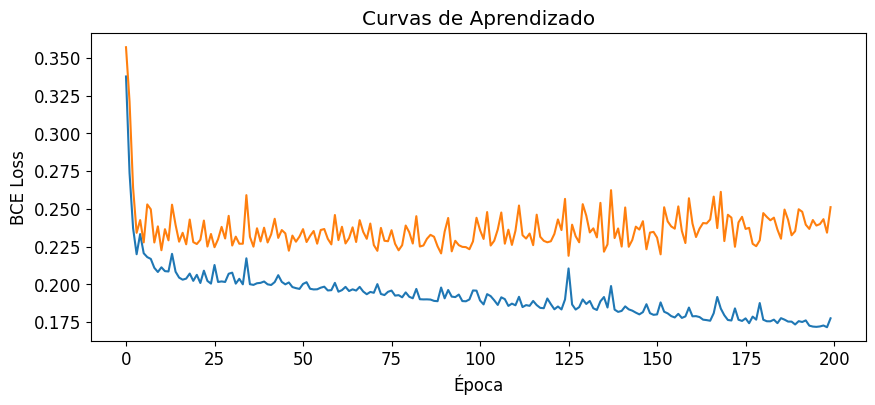

In [39]:
# --- 3. FUNÇÃO DE CUSTO + OTIMIZAÇÃO ---
loss_fn   = nn.BCELoss()                                           # Define a função de perda: Binary Cross-Entropy (equivalente ao MLE para distribuição Bernoulli)
otimizador = optim.Adam(modelo.parameters(), lr=0.01)              # Cria otimizador Adam com lr=0.01 (SGD com momentos adaptativos de 1ª e 2ª ordem)

# --- 4. LOOP DE TREINAMENTO ---
N_EPOCHS  = 200                                                    # Número total de épocas de treino
BATCH     = 32                                                     # Tamanho do mini-batch (32 amostras por atualização)
hist_train, hist_test = [], []                                     # Listas para armazenar o histórico de perdas de treino e teste por época

for epoch in range(N_EPOCHS):                                      # Loop principal: itera sobre as 200 épocas
    modelo.train()                                                 # Coloca o modelo em modo treino (ativa dropout/batchnorm se houver)
    perm = torch.randperm(X_train_t.shape[0])                     # Gera permutação aleatória dos índices (embaralha os dados a cada época)
    for i in range(0, X_train_t.shape[0], BATCH):                 # Loop interno: itera sobre os mini-batches (0, 32, 64, ..., 640)
        idx = perm[i:i+BATCH]                                     # Seleciona os índices do mini-batch atual
        Xb, yb = X_train_t[idx], y_train_t[idx]                   # Extrai o mini-batch de inputs e targets
        otimizador.zero_grad()                                     # Zera os gradientes acumulados do passo anterior
        pred = modelo(Xb)                                          # Forward pass: calcula as predições (probabilidades entre 0 e 1)
        loss = loss_fn(pred, yb)                                   # Calcula a BCE loss entre predições e targets no mini-batch
        loss.backward()                                            # Backward pass: calcula os gradientes de todos os parâmetros
        otimizador.step()                                          # Atualiza os pesos usando Adam (w = w - lr * gradiente_adaptado)

    modelo.eval()                                                  # Coloca o modelo em modo avaliação (desativa dropout/batchnorm)
    with torch.no_grad():                                          # Desativa cálculo de gradientes (economia de memória e tempo)
        loss_tr = loss_fn(modelo(X_train_t), y_train_t).item()     # Calcula a perda no dataset de treino completo e extrai o escalar
        loss_te = loss_fn(modelo(X_test_t),  y_test_t ).item()     # Calcula a perda no dataset de teste completo
        hist_train.append(loss_tr)                                 # Registra a perda de treino desta época
        hist_test.append(loss_te)                                  # Registra a perda de teste desta época

# Acurácia final
with torch.no_grad():                                              # Sem gradientes para a avaliação final
    pred_te = (modelo(X_test_t) >= 0.5).float()                   # Converte probabilidades em classes: ≥0.5 → 1, <0.5 → 0
    acc = (pred_te == y_test_t).float().mean().item()              # Compara predições com targets, calcula a fração de acertos (acurácia)

print(f'Acurácia no teste: {acc*100:.1f}%')                       # Imprime a acurácia final em porcentagem

# Curvas de aprendizado
plt.figure(figsize=(10, 4))                                        # Cria figura de 10x4 polegadas
plt.plot(hist_train, label='Perda Treino')                         # Plota a curva de perda de treino ao longo das épocas
plt.plot(hist_test,  label='Perda Teste')                          # Plota a curva de perda de teste ao longo das épocas
plt.xlabel('Época')                                                # Rótulo do eixo X
plt.ylabel('BCE Loss')                                             # Rótulo do eixo Y: Binary Cross-Entropy Loss
plt.title('Curvas de Aprendizado')                                 # Título

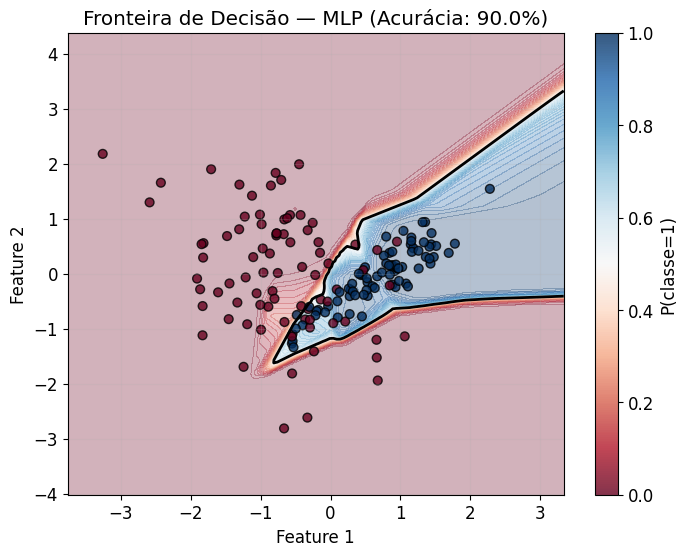

In [41]:
# Fronteira de decisão aprendida

h = 0.05                                                           # Define o passo da grade (resolução da fronteira — quanto menor, mais detalhada)
x_min, x_max = X_np[:,0].min()-0.5, X_np[:,0].max()+0.5           # Calcula limites do eixo X com margem de 0.5 unidade para cada lado
y_min, y_max = X_np[:,1].min()-0.5, X_np[:,1].max()+0.5           # Calcula limites do eixo Y com margem de 0.5 unidade
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))  # Cria grade 2D cobrindo todo o espaço (cada ponto será classificado)

grade = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)  # Achata a grade em pares (x,y), concatena em colunas e converte para tensor (n_pontos, 2)
modelo.eval()                                                      # Coloca o modelo em modo avaliação
with torch.no_grad():                                              # Desativa gradientes (não estamos treinando)
    Z = modelo(grade).numpy().reshape(xx.shape)                    # Passa toda a grade pelo modelo, converte para NumPy e reshape para a forma 2D da grade

plt.figure(figsize=(8, 6))                                         # Cria figura de 8x6 polegadas
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=50)       # Plota mapa de calor contínuo das probabilidades P(classe=1), com 50 níveis de cor (vermelho↔azul)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)  # Desenha a linha de contorno onde P=0.5 — esta é a fronteira de decisão real do modelo
plt.scatter(X_te[:,0], X_te[:,1], c=y_te, cmap='RdBu', edgecolors='k', s=40, alpha=0.8)  # Plota os pontos de teste coloridos pela classe real (mesma paleta RdBu)
plt.title(f'Fronteira de Decisão — MLP (Acurácia: {acc*100:.1f}%)')  # Título com o nome do modelo e acurácia
plt.xlabel('Feature 1')                                            # Rótulo do eixo X
plt.ylabel('Feature 2')                                            # Rótulo do eixo Y
plt.colorbar(label='P(classe=1)')                                  # Adiciona barra de cores lateral mostrando a escala de probabilidade
plt.grid(True, alpha=0.2)                                         # Grade com 20% de transparência
plt.show()                                                         # Renderiza e exibe

---

## 11. Desafios que Motivam Deep Learning (~8 min)

A Seção 5.11 é a **ponte conceitual** entre ML clássico e Deep Learning. Os algoritmos tradicionais funcionam bem em muitos problemas, mas falham nas tarefas centrais de IA (reconhecimento de fala, visão, linguagem). O livro identifica **três desafios** fundamentais:

### 11.1 A Maldição da Dimensionalidade

O número de configurações possíveis cresce **exponencialmente** com o número de dimensões. Se distinguimos $v$ valores por dimensão em $d$ dimensões, precisamos de $O(v^d)$ exemplos para cobrir o espaço.

> Em 1D com 10 regiões: 10 exemplos bastam. Em 10D: precisamos de $10^{10}$ exemplos!

### 11.2 Suavidade Local e suas Limitações

Algoritmos como k-NN, kernel machines e árvores de decisão dependem da hipótese de **suavidade local**: $f(x) \approx f(x + \epsilon)$ para $\epsilon$ pequeno. Cada exemplo só informa sobre sua vizinhança imediata, resultando em $O(k)$ regiões para $O(k)$ exemplos.

Deep Learning supera isso: com $O(k)$ parâmetros, uma rede profunda pode representar $O(2^k)$ regiões, porque **introduz dependências entre regiões** via composição hierárquica de features.

### 11.3 Manifold Learning

A **hipótese do manifold**: dados reais (imagens, áudio, texto) se concentram em **variedades de baixa dimensão** imersos em espaços de alta dimensão. Imagens aleatórias são ruído — imagens "reais" ocupam uma fração ínfima do espaço de pixels.

Se os dados vivem em um manifold de dimensão $d_{manifold} \ll d_{total}$, precisamos de muito menos exemplos do que o espaço total sugeriria.

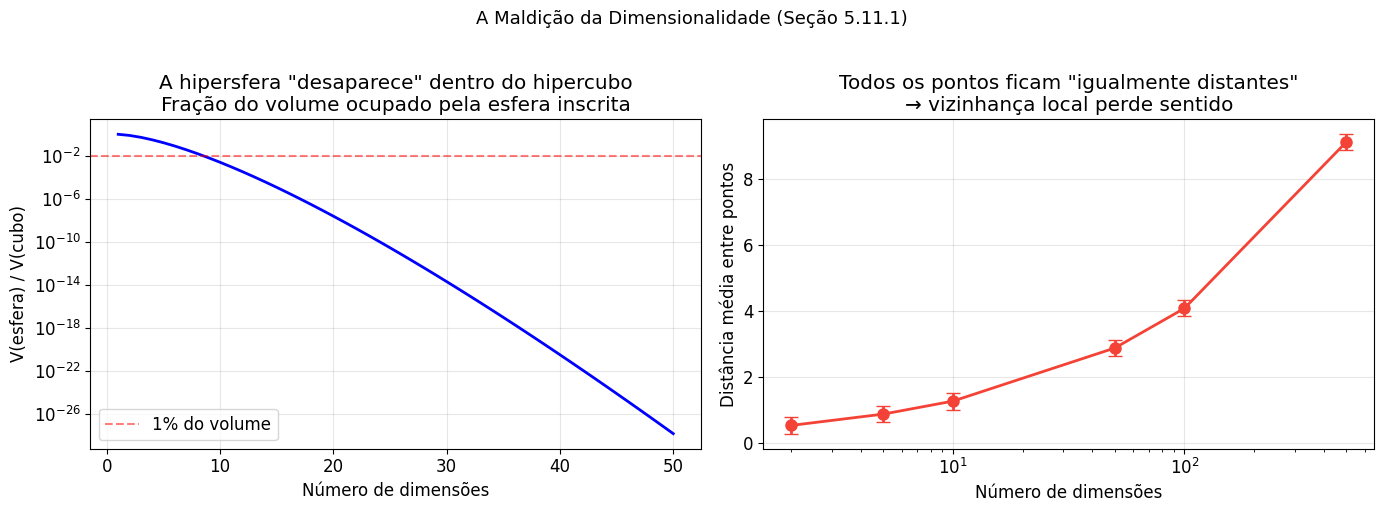

Em alta dimensão:
  - A esfera inscrita ocupa 1.54e-26% do cubo em 50D
  - Distância média entre pontos em 500D: 9.1 ± 0.2 (pontos se "espalham")


In [42]:
# Maldição da Dimensionalidade: volume da hipersfera colapsa

from scipy.special import gamma as gamma_fn                        # Importa a função Gamma (generalização do fatorial) para calcular volumes de hiperesferas

def volume_hipersfera(d, r=1.0):                                   # Define função que calcula o volume de uma hipersfera de raio r em d dimensões
    """Volume de uma hipersfera de raio r em d dimensões."""
    return (np.pi**(d/2) / gamma_fn(d/2 + 1)) * r**d              # Fórmula: V = π^(d/2) / Γ(d/2 + 1) * r^d — generalização de πr² (2D) e 4/3πr³ (3D)

def volume_hipercubo(d, lado=2.0):                                 # Define função que calcula o volume de um hipercubo de lado 'lado' em d dimensões
    """Volume de um hipercubo de lado 'lado' em d dimensões."""
    return lado**d                                                 # Volume é simplesmente lado^d (2^d para lado=2)

dims = np.arange(1, 51)                                            # Cria array de dimensões de 1 a 50
razoes = [volume_hipersfera(d) / volume_hipercubo(d) for d in dims]  # Calcula a razão esfera/cubo para cada dimensão (fração do cubo que a esfera ocupa)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))                   # Cria figura com 2 subplots lado a lado (14x5 polegadas)

# Razão volume esfera/cubo
axes[0].plot(dims, razoes, 'b-', lw=2)                            # Plota a razão de volumes em função da dimensão (curva azul)
axes[0].set_xlabel('Número de dimensões')                          # Rótulo do eixo X
axes[0].set_ylabel('V(esfera) / V(cubo)')                         # Rótulo do eixo Y: fração volumétrica
axes[0].set_title('A hipersfera "desaparece" dentro do hipercubo\nFração do volume ocupado pela esfera inscrita')  # Título descritivo
axes[0].set_yscale('log')                                         # Escala logarítmica no eixo Y (a razão cai exponencialmente)
axes[0].grid(True, alpha=0.3)                                     # Grade com 30% de transparência
axes[0].axhline(0.01, color='red', ls='--', alpha=0.5, label='1% do volume')  # Linha horizontal em 1% como referência visual
axes[0].legend()                                                   # Exibe legenda

# Distância média entre pontos uniformes cresce com d
n_pontos = 1000                                                    # Gera 1000 pontos para cada experimento
dims_teste = [2, 5, 10, 50, 100, 500]                             # Dimensões a testar (de baixa a muito alta)
dist_medias = []                                                   # Lista para armazenar tuplas (média, desvio) das distâncias

for d in dims_teste:                                               # Itera sobre cada dimensão
    pontos = np.random.uniform(0, 1, (n_pontos, d))               # Gera 1000 pontos uniformes no hipercubo [0,1]^d
    # Distâncias entre pares aleatórios
    idx = np.random.choice(n_pontos, (500, 2), replace=True)      # Sorteia 500 pares aleatórios de índices (com reposição)
    dists = np.linalg.norm(pontos[idx[:,0]] - pontos[idx[:,1]], axis=1)  # Calcula a distância euclidiana entre cada par de pontos
    dist_medias.append((np.mean(dists), np.std(dists)))            # Armazena a média e o desvio padrão das 500 distâncias

medias = [x[0] for x in dist_medias]                              # Extrai só as médias
stds = [x[1] for x in dist_medias]                                # Extrai só os desvios padrão

axes[1].errorbar(dims_teste, medias, yerr=stds, fmt='o-', color='#F44336', lw=2, capsize=5, ms=8)  # Plota médias com barras de erro (desvio padrão) em vermelho
axes[1].set_xlabel('Número de dimensões')                          # Rótulo do eixo X
axes[1].set_ylabel('Distância média entre pontos')                 # Rótulo do eixo Y
axes[1].set_title('Todos os pontos ficam "igualmente distantes"\n→ vizinhança local perde sentido')  # Título: consequência para algoritmos como k-NN
axes[1].set_xscale('log')                                         # Escala logarítmica no eixo X (dimensões variam de 2 a 500)
axes[1].grid(True, alpha=0.3)                                     # Grade com 30% de transparência

plt.suptitle('A Maldição da Dimensionalidade (Seção 5.11.1)', fontsize=13, y=1.02)  # Título geral
plt.tight_layout()                                                 # Ajusta espaçamento
plt.show()                                                         # Renderiza e exibe

print('Em alta dimensão:')                                         # Imprime resumo dos resultados
print(f'  - A esfera inscrita ocupa {razoes[-1]*100:.2e}% do cubo em {dims[-1]}D')  # Mostra a razão para 50D (valor ínfimo)
print(f'  - Distância média entre pontos em 500D: {medias[-1]:.1f} ± {stds[-1]:.1f} (pontos se "espalham")')  # Mostra distância média em 500D

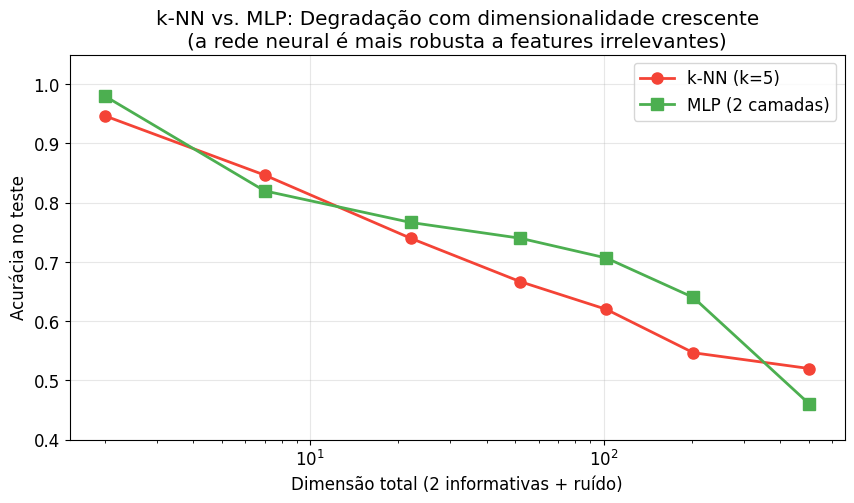

k-NN depende de distância euclidiana → features de ruído destroem a vizinhança
MLP aprende a ignorar features irrelevantes via pesos → mais robusta


In [44]:
# k-NN falha com alta dimensionalidade (suavidade local não basta)
# Teste: mesmo problema, embedding em dimensões crescentes com features de ruído

from sklearn.neighbors import KNeighborsClassifier                 # Importa o classificador k-NN

np.random.seed(42)                                                 # Fixa semente para reprodutibilidade

# Dataset base: 2 features informativas
n_base = 500                                                       # Define 500 amostras
X_base, y_base = make_classification(n_samples=n_base, n_features=2, n_informative=2,  # Gera dataset com 2 features, ambas informativas
                                      n_redundant=0, n_clusters_per_class=1, random_state=42)  # Sem redundância, 1 cluster por classe

dims_ruido = [0, 5, 20, 50, 100, 200, 500]                        # Quantidades de features de ruído a adicionar (de 0 a 500)
acc_knn = []                                                       # Lista para armazenar acurácias do k-NN
acc_mlp_dim = []                                                   # Lista para armazenar acurácias da MLP

for d_noise in dims_ruido:                                         # Itera sobre cada quantidade de ruído
    # Adiciona d_noise features de ruído
    X_ruido = np.hstack([X_base, np.random.randn(n_base, d_noise)]) if d_noise > 0 else X_base.copy()  # Concatena d_noise colunas gaussianas aleatórias ao dataset original (ou copia se d_noise=0)

    X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(X_ruido, y_base, test_size=0.3, random_state=42)  # Separa 70% treino, 30% teste

    # Normalizar
    sc_d = StandardScaler()                                        # Cria normalizador
    X_tr_d = sc_d.fit_transform(X_tr_d)                            # Ajusta e transforma o treino (média 0, desvio 1 por feature)
    X_te_d = sc_d.transform(X_te_d)                                # Transforma o teste com as estatísticas do treino

    # k-NN
    knn = KNeighborsClassifier(n_neighbors=5)                      # Cria k-NN com 5 vizinhos
    knn.fit(X_tr_d, y_tr_d)                                        # Treina (memoriza os dados de treino)
    acc_knn.append(knn.score(X_te_d, y_te_d))                     # Calcula e armazena a acurácia no teste

    # MLP simples (2 camadas)
    d_total = 2 + d_noise                                          # Dimensão total das features (2 informativas + ruído)
    mlp_d = nn.Sequential(                                         # Cria rede neural sequencial
        nn.Linear(d_total, 32), nn.ReLU(),                         # Camada 1: d_total → 32 neurônios + ReLU
        nn.Linear(32, 16), nn.ReLU(),                              # Camada 2: 32 → 16 neurônios + ReLU
        nn.Linear(16, 1), nn.Sigmoid()                             # Camada 3: 16 → 1 saída + Sigmoid (probabilidade)
    )
    opt_d = optim.Adam(mlp_d.parameters(), lr=0.01)                # Otimizador Adam com lr=0.01
    loss_d = nn.BCELoss()                                          # Função de perda: Binary Cross-Entropy

    X_tr_t_d = torch.tensor(X_tr_d, dtype=torch.float32)           # Converte X treino para tensor
    y_tr_t_d = torch.tensor(y_tr_d, dtype=torch.float32).unsqueeze(1)  # Converte y treino para tensor (n,1)
    X_te_t_d = torch.tensor(X_te_d, dtype=torch.float32)           # Converte X teste para tensor

    for _ in range(150):                                           # Treina por 150 épocas (batch completo, sem mini-batch)
        mlp_d.train()                                              # Modo treino
        opt_d.zero_grad()                                          # Zera gradientes
        loss_d(mlp_d(X_tr_t_d), y_tr_t_d).backward()              # Forward + loss + backward em uma linha
        opt_d.step()                                               # Atualiza pesos

    mlp_d.eval()                                                   # Modo avaliação
    with torch.no_grad():                                          # Sem gradientes
        pred_d = (mlp_d(X_te_t_d) >= 0.5).float().numpy().flatten()  # Prediz classes: probabilidade → 0/1 → NumPy → vetor 1D
    acc_mlp_dim.append(np.mean(pred_d == y_te_d))                  # Calcula acurácia (fração de acertos) e armazena

total_dims = [2 + d for d in dims_ruido]                           # Calcula a dimensão total para cada experimento (para o eixo X do gráfico)

plt.figure(figsize=(10, 5))                                        # Cria figura de 10x5 polegadas
plt.plot(total_dims, acc_knn, 'o-', color='#F44336', lw=2, ms=8, label='k-NN (k=5)')       # Plota acurácia do k-NN em vermelho
plt.plot(total_dims, acc_mlp_dim, 's-', color='#4CAF50', lw=2, ms=8, label='MLP (2 camadas)')  # Plota acurácia da MLP em verde
plt.xlabel('Dimensão total (2 informativas + ruído)')              # Rótulo do eixo X
plt.ylabel('Acurácia no teste')                                    # Rótulo do eixo Y
plt.title('k-NN vs. MLP: Degradação com dimensionalidade crescente\n(a rede neural é mais robusta a features irrelevantes)')  # Título descritivo
plt.legend(fontsize=12)                                            # Legenda com fonte tamanho 12
plt.grid(True, alpha=0.3)                                         # Grade com 30% de transparência
plt.xscale('log')                                                  # Escala logarítmica no eixo X (dimensões vão de 2 a 502)
plt.ylim(0.4, 1.05)                                               # Fixa limites do eixo Y entre 40% e 105%
plt.show()                                                         # Renderiza e exibe

print('k-NN depende de distância euclidiana → features de ruído destroem a vizinhança')  # Explica por que k-NN degrada
print('MLP aprende a ignorar features irrelevantes via pesos → mais robusta')             # Explica por que MLP resiste melhor

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_82120\1818839425.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()                                                 # Ajusta espaçamento


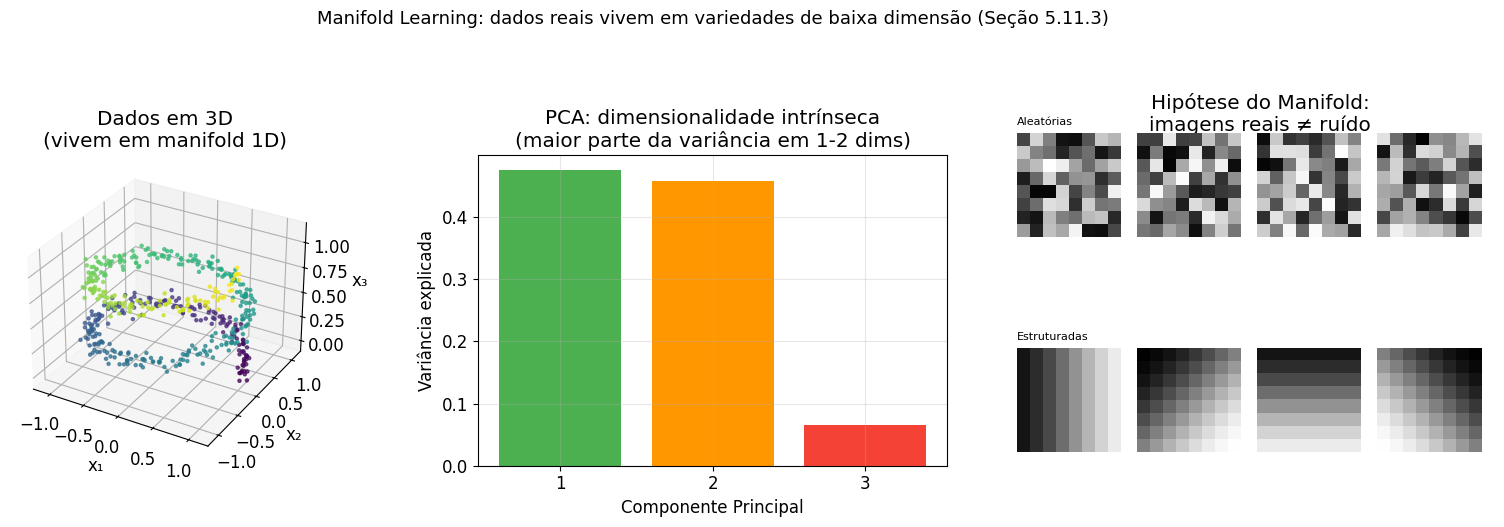

A hipótese do manifold explica por que deep learning funciona:
→ Não precisamos cobrir todo o espaço R^n
→ Basta aprender a estrutura do manifold de baixa dimensão
→ Redes profundas aprendem representações hierárquicas desses manifolds


In [45]:
# Manifold Learning: dados de alta dimensão vivem em variedades de baixa dimensão

from sklearn.decomposition import PCA                              # Importa PCA para análise de componentes principais

np.random.seed(42)                                                 # Fixa semente para reprodutibilidade

# Simular dados em um manifold: curva (1D) imersa em 3D
t = np.linspace(0, 4*np.pi, 500)                                  # Cria 500 valores de 0 a 4π — o parâmetro intrínseco 1D da curva
X_manifold_3d = np.column_stack([                                  # Empilha 3 colunas para criar dados 3D que vivem numa hélice 1D
    np.cos(t) + np.random.randn(500)*0.05,                        # Coordenada x: cos(t) + ruído pequeno (desvio 0.05)
    np.sin(t) + np.random.randn(500)*0.05,                        # Coordenada y: sin(t) + ruído pequeno
    t / (4*np.pi) + np.random.randn(500)*0.05                     # Coordenada z: t normalizado (sobe linearmente) + ruído — forma a hélice
])

fig = plt.figure(figsize=(16, 5))                                 # Cria figura de 16x5 polegadas

# Plot 3D do manifold
ax1 = fig.add_subplot(131, projection='3d')                        # Cria subplot 3D (primeiro de 3)
ax1.scatter(X_manifold_3d[:,0], X_manifold_3d[:,1], X_manifold_3d[:,2],  # Plota os 500 pontos no espaço 3D
            c=t, cmap='viridis', s=5, alpha=0.7)                  # Coloridos pelo parâmetro t (viridis: amarelo→verde→azul), pontos pequenos
ax1.set_title('Dados em 3D\n(vivem em manifold 1D)')              # Título: apesar de 3D, a dimensão intrínseca é 1
ax1.set_xlabel('x₁')                                              # Rótulo eixo X
ax1.set_ylabel('x₂')                                              # Rótulo eixo Y
ax1.set_zlabel('x₃')                                              # Rótulo eixo Z

# PCA: variância explicada mostra dimensionalidade intrínseca
pca = PCA().fit(X_manifold_3d)                                    # Ajusta PCA com todas as 3 componentes nos dados 3D
ax2 = fig.add_subplot(132)                                         # Cria subplot central (2D)
ax2.bar(range(1, 4), pca.explained_variance_ratio_, color=['#4CAF50', '#FF9800', '#F44336'])  # Barras: variância explicada por cada componente (verde, laranja, vermelho)
ax2.set_xlabel('Componente Principal')                             # Rótulo eixo X
ax2.set_ylabel('Variância explicada')                              # Rótulo eixo Y
ax2.set_title('PCA: dimensionalidade intrínseca\n(maior parte da variância em 1-2 dims)')  # Título: PCA revela que 1-2 componentes bastam
ax2.set_xticks([1, 2, 3])                                         # Define ticks do eixo X como 1, 2, 3
ax2.grid(True, alpha=0.3)                                         # Grade com 30% de transparência

# Imagens aleatórias vs. "reais" — a hipótese do manifold
ax3 = fig.add_subplot(133)                                         # Cria subplot da direita (será usado como contêiner visual)
# Gerar "imagens" aleatórias de 8x8
imgs_random = np.random.uniform(0, 1, (4, 8, 8))                  # Gera 4 imagens 8x8 com pixels aleatórios uniformes — representam pontos genéricos em R^64
# Gerar "imagens" estruturadas (gradientes simples — simulam manifold)
imgs_struct = []                                                   # Lista para imagens estruturadas
for i in range(4):                                                 # Gera 4 imagens com padrão de gradiente direcional
    angle = np.pi * i / 4                                         # Ângulo do gradiente: 0°, 45°, 90°, 135°
    x_g = np.linspace(-1, 1, 8)                                   # Coordenadas x da grade 8x8
    y_g = np.linspace(-1, 1, 8)                                   # Coordenadas y da grade 8x8
    xx_g, yy_g = np.meshgrid(x_g, y_g)                            # Cria grade 2D
    img = 0.5 + 0.5 * np.sin(xx_g * np.cos(angle) + yy_g * np.sin(angle))  # Gera padrão senoidal na direção do ângulo (simula imagem "real" com estrutura)
    imgs_struct.append(img)                                        # Adiciona à lista

for i in range(4):                                                 # Itera para posicionar as 8 mini-imagens manualmente
    # Random
    ax_sub1 = fig.add_axes([0.69 + i*0.075, 0.55, 0.065, 0.3])   # Cria mini-eixo na posição específica (linha superior) para imagem aleatória
    ax_sub1.imshow(imgs_random[i], cmap='gray', vmin=0, vmax=1)   # Exibe a imagem aleatória em escala de cinza
    ax_sub1.axis('off')                                            # Remove eixos da mini-imagem
    if i == 0: ax_sub1.set_title('Aleatórias', fontsize=8, loc='left')  # Título só na primeira imagem da linha

    # Structured
    ax_sub2 = fig.add_axes([0.69 + i*0.075, 0.12, 0.065, 0.3])   # Cria mini-eixo na posição específica (linha inferior) para imagem estruturada
    ax_sub2.imshow(imgs_struct[i], cmap='gray', vmin=0, vmax=1)   # Exibe a imagem estruturada em escala de cinza
    ax_sub2.axis('off')                                            # Remove eixos
    if i == 0: ax_sub2.set_title('Estruturadas', fontsize=8, loc='left')  # Título só na primeira

ax3.axis('off')                                                    # Desativa os eixos do subplot contêiner (serve só de fundo)
ax3.set_title('Hipótese do Manifold:\nimagens reais ≠ ruído', y=1.05)  # Título do painel direito

plt.suptitle('Manifold Learning: dados reais vivem em variedades de baixa dimensão (Seção 5.11.3)',  # Título geral
             fontsize=13, y=1.05)
plt.tight_layout()                                                 # Ajusta espaçamento
plt.show()                                                         # Renderiza e exibe

print('A hipótese do manifold explica por que deep learning funciona:')      # Imprime explicação textual
print('→ Não precisamos cobrir todo o espaço R^n')                           # Ponto 1: o espaço completo é imenso demais
print('→ Basta aprender a estrutura do manifold de baixa dimensão')          # Ponto 2: os dados reais ocupam uma fatia ínfima
print('→ Redes profundas aprendem representações hierárquicas desses manifolds')  # Ponto 3: deep learning é eficaz justamente por explorar essa estrutura

---

## Resumo

| Conceito | Ponto-chave |
|----------|-------------|
| **Aprendizado** | Melhorar desempenho (P) em tarefa (T) com experiência (E) |
| **Regressão Linear** | Primeiro algoritmo completo: solução fechada via equações normais |
| **Capacidade** | Equilíbrio entre under e overfitting é o desafio central |
| **Regularização** | L2 controla norma dos pesos; L1 promove esparsidade |
| **Conjuntos** | Treino → parâmetros \| Validação → hiperparâmetros \| Teste → avaliação final |
| **Viés-Variância** | MSE = Viés² + Variância — trade-off inevitável |
| **Consistência** | Estimador converge para θ* com m → ∞ |
| **MLE** | Maximizar log-likelihood ≡ minimizar KL divergence ≡ minimizar cross-entropy |
| **MAP/Bayes** | MAP com prior gaussiana ≡ MLE + regularização L2 |
| **Algoritmos clássicos** | k-NN, SVM, árvores: dependem de suavidade local |
| **SGD** | Mini-batches: equilíbrio entre velocidade e estabilidade |
| **Pipeline** | Dataset + Modelo + Loss + Otimizador |
| **Maldição da dimensionalidade** | Espaço cresce exponencialmente → exemplos ficam esparsos |
| **Manifold Learning** | Dados reais vivem em variedades de baixa dimensão |
| **Deep Learning** | Supera suavidade local via composição hierárquica de features |

### Conexão com PINNs

Em **Physics-Informed Neural Networks** (tema da disciplina), todos esses conceitos se aplicam diretamente:
- O **modelo** é uma rede que aproxima a solução de uma EDO/EDP
- A **função de custo** inclui tanto resíduo da equação diferencial quanto condições de contorno → **MLE** do resíduo + **regularização** pela física
- O **otimizador** (Adam/SGD) minimiza esse custo composto
- **Overfitting** pode ocorrer quando a rede memoriza pontos de treinamento mas viola a física
- A **hipótese do manifold** é especialmente relevante: soluções de EDPs vivem em variedades de baixa dimensão no espaço de funções
- Deep Learning supera a **maldição da dimensionalidade** que limita métodos numéricos clássicos (FEM, FDM) em alta dimensão

---

### Referências

- Goodfellow, I., Bengio, Y., Courville, A. (2016). *Deep Learning*, Cap. 5. MIT Press.
- PyTorch Documentation: https://pytorch.org/docs/stable/
- Raissi, M. et al. (2019). *Physics-informed neural networks.* Journal of Computational Physics.
- Mitchell, T. (1997). *Machine Learning.* McGraw-Hill.